# Final AQI Validation Notebook

This notebook trains `aqi_model_3`, then runs internal validation, unseen external validation, grouped diagnostics, traditional ML baselines, AE-vs-raw LSTM comparisons, and feature-finding summaries.

## 1. Imports and project paths

In [22]:
# Use average of the mean for each feature to get gaussian distribution for the autoencoder, which is what it learns best. This is a common practice to improve AE performance when features have different scales or distributions.

import logging
import os
import time
import pickle
import warnings
import json
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.INFO,
                    # filename='autoencoder_training.log',
                    # filemode='w',
                    format='%(levelname)s: %(message)s',
                    force=True)
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.info(f'Logger name: {logger.name} and level: {logger.level}')



INFO: Logger name: __main__ and level: 20


In [23]:
# ============================================================
# Config
# ============================================================

@dataclass
class Config:
    all_data_path: str = "data/all_features_training.csv"

    # Split/scaling choices
    val_size: float = 0.20
    random_state: int = 10
    scalers = [MinMaxScaler(), StandardScaler()]
    # Sequence settings for LSTM
    lookback: int = 24 # The number of previous sequences to "lookback" on
    horizon: int = 1 # The number of hour(s) to predict ahead

    # AE settings
    latent_dim: int = 8
    ae_layers = [[16, 4], [8]]
    ae_hidden_dims: List[int] = field(default_factory=list)  # single bottleneck layer only
    ae_epochs: int = 50
    ae_lr: float = 1e-3
    ae_batch_size: int = 1048

    # LSTM settings
    lstm_hidden: int = 96
    lstm_layers: int = 1
    lstm_dropout: float = 1e-4
    lstm_epochs: int = 50
    lstm_lr: float = .00099
    patience: int = 5
    lstm_batch_size = 4096

    seed: int = 42
    show_plots: bool = True
    save_dir: str = "models"
    external_validation_path: str = "data/all_features_validation.csv"
###########################################################################
    # THESE COLUMNS ARE IRRELEVANT AND ARE DROPPED BECAUSE NOT NEEDED
    cols_to_drop: List[str] = field(default_factory=lambda: [
        'wind_speed_100m', 'month', 'day', 'hour',
        'day_of_week', 'day_of_year', 'month_sin', 'month_cos']
        )
###########################################################################
    @property
    def device(self) -> torch.device:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [24]:
# ============================================================
# Models
# ============================================================

class AQI_LSTM(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int = 64,
                num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)
    

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class TimeVariantAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 16, scaler=StandardScaler()):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, latent_dim),
            nn.LeakyReLU(),
        )
        if isinstance(scaler, MinMaxScaler):
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, input_dim),
                nn.Sigmoid()
            )
        else:
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, input_dim)
            )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        encoded = self.encoder(x)
        recon = self.decoder(encoded)
        return recon, encoded

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)


In [25]:
# ============================================================
# Data pipeline
# ============================================================

class AIQTrainingPipeline:
    """Prepare aiq_training_cam using the notebook's feature/scaling logic."""

    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.dataset_df = self.load_data(cfg.all_data_path)

        if self.dataset_df is None:
            raise ValueError("Failed to load data. Please check the file path and contents.")
        self.feature_cols: List[str] = []
        self.cyclic_cols = None
        self.binary_cols = None
        self.lag_cols = None
        self.target_col = "us_aqi"

        self.remove_nan()
        self.remove_uninformative_features()
        self.identify_features()

        self.train_df, self.val_df = self.split_data()

    def load_data(self, dataset_path):
        dataset = pd.read_csv(dataset_path)

        if dataset.empty:
            logger.warning("The loaded DataFrame is empty. Please check the file path and contents.")
            return None
        else:
            logger.info(f"Data loaded successfully with shape: {dataset.shape}")
            logger.info(f'DataFrame columns: {dataset.columns.tolist()}')

        return dataset

    def remove_nan(self):
        initial_shape = self.dataset_df.shape
        self.dataset_df.dropna(inplace=True)
        logger.info(f"Removed NaN values. Shape changed from {initial_shape} to {self.dataset_df.shape}")

    def remove_uninformative_features(self):
        self.dataset_df.drop(columns=self.cfg.cols_to_drop, inplace=True, errors='ignore')
        logger.info(f"Removed uninformative features: {self.cfg.cols_to_drop}")

    def identify_cyclic_features(self):
        cyclic_postfixes = ['_sin', '_cos']
        self.cyclic_cols = [col for col in self.dataset_df.columns if any(col.endswith(postfix) for postfix in cyclic_postfixes)]
        logger.info(f"Identified cyclic features: {self.cyclic_cols}")

    def identify_binary_features(self):
        self.binary_cols = [col for col in self.dataset_df.columns if self.dataset_df[col].nunique() == 2 and col not in self.cyclic_cols]
        logger.info(f"Identified binary features: {self.binary_cols}")

    def identify_lag_features(self):
        lag_prefixes = [
            'us_aqi_past_',
            'pm2_5_past_',
            'ozone_past_',
            'wind_speed_100m_past_',
            'wind_direction_100m_sin_past_',
            'wind_direction_100m_cos_past_',
        ]
        self.lag_cols = [col for col in self.dataset_df.columns if any(col.startswith(prefix) for prefix in lag_prefixes)]
        logger.info(f"Identified lag features: {self.lag_cols}")

    def identify_feature_cols(self):
        remove_cols = ['zip', 'time', 'us_aqi'] + self.cyclic_cols + self.binary_cols + self.lag_cols
        self.feature_cols = [col for col in self.dataset_df.columns if col not in remove_cols]
        logger.info(f"Feature columns: {self.feature_cols}")
        logger.info(f"Number of feature columns: {len(self.feature_cols)}")
    
    def identify_features(self):
        self.identify_cyclic_features()
        self.identify_binary_features()
        self.identify_lag_features()
        self.identify_feature_cols()

    def split_data(self):
        train_parts = []
        val_parts = []

        for zip_code, group in self.dataset_df.groupby("zip"):
            group = group.sort_values("time").reset_index(drop=True)
            split_idx_train = int(len(group) * (1 - self.cfg.val_size))

            train_parts.append(group.iloc[:split_idx_train].copy())
            val_parts.append(group.iloc[split_idx_train:].copy())

        train_df = pd.concat(train_parts, axis=0).reset_index(drop=True)
        val_df = pd.concat(val_parts, axis=0).reset_index(drop=True)

        return train_df, val_df
    
    def scale_features(self, unscaled_train_df: pd.DataFrame, unscaled_val_df: pd.DataFrame, scaler) -> Tuple[np.ndarray, np.ndarray]:
        scaled_train = scaler.fit_transform(unscaled_train_df[self.feature_cols])
        scaled_val = scaler.transform(unscaled_val_df[self.feature_cols])

        return scaled_train, scaled_val

    @property
    def input_dim(self) -> int:
        return len(self.feature_cols)

    # Create 24 hour window sequences for LSTM training, grouped by zip code to maintain temporal integrity. Each sequence includes the past `lookback` hours of features
    def make_lstm_sequences(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        lookback, horizon = self.cfg.lookback, self.cfg.horizon
        Xs, ys = [], []

        for zip_code, group in df.groupby("zip"):
            group = group.sort_values("time").reset_index(drop=True)

            X = group.drop(columns=[self.target_col, 'zip', 'time']).to_numpy(dtype=np.float32)
            y = group[self.target_col].to_numpy(dtype=np.float32)

            if len(group) < lookback + horizon:
                continue
            
            for i in range(len(group) - lookback - horizon + 1):
                Xs.append(X[i:i+lookback]) # past `lookback` hours of features
                ys.append(y[i+lookback+horizon-1]) # target is the AQI at the end of the horizon

        return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


In [26]:
# ============================================================
# AE reducer
# ============================================================

class AEReducer:
    def __init__(self, cfg: Config, input_dim: int, scaler=StandardScaler()):
        self.cfg = cfg
        self.model = TimeVariantAutoencoder(input_dim=input_dim, latent_dim=cfg.latent_dim, scaler=scaler)
        self.train_history: List[float] = []

    def fit(self, X_train: np.ndarray):
        loader = DataLoader(
            TensorDataset(torch.tensor(X_train, dtype=torch.float32)),
            batch_size=self.cfg.ae_batch_size,
            shuffle=True,
            drop_last=False,
        )

        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.cfg.ae_lr, weight_decay=1e-5)
        self.model.to(self.cfg.device).train()
        self.train_history = []

        for epoch in range(self.cfg.ae_epochs):
            total = 0.0
            t0 = time.time()
            for (batch,) in loader:
                batch = batch.to(self.cfg.device)
                optimizer.zero_grad()
                recon, _ = self.model(batch)
                loss = criterion(recon, batch)
                loss.backward()
                optimizer.step()
                total += loss.item()

            avg = total / len(loader)
            self.train_history.append(avg)
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"    [AE] Epoch {epoch+1:3d}/{self.cfg.ae_epochs}  loss={avg:.6f}  ({time.time()-t0:.1f}s)")

    def transform(self, X: np.ndarray) -> np.ndarray:
        self.model.eval()
        with torch.no_grad():
            X_t = torch.tensor(X, dtype=torch.float32).to(self.cfg.device)
            z = self.model.encode(X_t)
        return z.cpu().numpy()

    def fit_transform(self, X_train: np.ndarray) -> np.ndarray:
        self.fit(X_train)
        return self.transform(X_train)


In [27]:
# ============================================================
# LSTM trainer
# ============================================================

class EarlyStopping:
    def __init__(self, patience: int = 10):
        self.patience = patience
        self.counter = 0
        self.best_loss = float("inf")
        self.best_state = None

    def step(self, model: nn.Module, val_loss: float) -> bool:
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

class LSTMTrainer:
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def _loader(self, X, y, shuffle: bool):
        return DataLoader(
            TensorDataset(
                torch.tensor(X, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32).unsqueeze(1),
            ),
            batch_size=self.cfg.lstm_batch_size,
            shuffle=shuffle,
        )

    def train(self, model, X_train, y_train, X_val, y_val, name="LSTM"):
        train_dl = self._loader(X_train, y_train, True)
        val_dl = self._loader(X_val, y_val, False)

        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.cfg.lstm_lr, weight_decay=1e-5)
        model.to(self.cfg.device)
        earlystopper = EarlyStopping(patience=self.cfg.patience)

        train_hist, val_hist = [], []

        for ep in range(self.cfg.lstm_epochs):
            model.train()

            train_loss = 0.0
            for xb, yb in train_dl:
                xb, yb = xb.to(self.cfg.device), yb.to(self.cfg.device)

                pred = model(xb) # forward pass

                optimizer.zero_grad()
                loss = criterion(pred, yb)
                loss.backward()

                nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Clip gradients that exceed norm of 1.0, which is [gradient * (1 / L2 norm of gradients)]
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_dl)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_dl:
                    xb, yb = xb.to(self.cfg.device), yb.to(self.cfg.device)
                    val_loss += criterion(model(xb), yb).item()
            val_loss /= len(val_dl)

            train_hist.append(train_loss)
            val_hist.append(val_loss)

            if (ep + 1) % 5 == 0 or ep == 0:
                print(f"    [{name}] Epoch {ep+1:3d}/{self.cfg.lstm_epochs}  train={train_loss:.6f}  test={val_loss:.6f}")

            if(earlystopper.step(model, val_loss)):
                print(f"    [{name}] Early stopping at epoch {ep+1}")
                break

        if earlystopper.best_state is not None:
            model.load_state_dict(earlystopper.best_state)
        return train_hist, val_hist

    @torch.no_grad()
    def predict(self, model, X):
        model.eval().to(self.cfg.device)
        preds = []
        for i in range(0, len(X), self.cfg.lstm_batch_size):
            batch = torch.tensor(X[i:i+self.cfg.lstm_batch_size], dtype=torch.float32).to(self.cfg.device)
            preds.append(model(batch).cpu().numpy())
        return np.concatenate(preds).flatten()

    def evaluate(self, y_true, y_pred, label=""):
        yt = y_true.reshape(-1) # ensure 1D for metric calculations
        yp = y_pred.reshape(-1)

        rmse = float(np.sqrt(mean_squared_error(yt, yp)))
        mae = float(mean_absolute_error(yt, yp))
        r2 = float(1 - np.sum((yt - yp) ** 2) / (np.sum((yt - yt.mean()) ** 2) + 1e-10))
        print(f"    [{label}] RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
        return {"label": label, "rmse": rmse, "mae": mae, "r2": r2, "y_true": yt, "y_pred": yp}


In [28]:
# ============================================================
# Save helpers
# ============================================================

def save_artifacts(save_dir: str, model: AQI_LSTM, ae_reducer: AEReducer,
                   pipeline: AIQTrainingPipeline, cfg: Config, metrics: Dict,
                   loss_curves: Tuple[List[float], List[float]],
                   lstm_input_dim: int):
    os.makedirs(save_dir, exist_ok=True)

    torch.save({
        "model_state_dict": model.state_dict(),
        "config": {
            "input_dim": lstm_input_dim,
            "hidden_size": cfg.lstm_hidden,
            "num_layers": cfg.lstm_layers,
            "lookback": cfg.lookback,
            "latent_dim": cfg.latent_dim,
            "feature_cols": pipeline.feature_cols,
            "target_col": pipeline.target_col,
        },
        "metrics": metrics,
        "train_loss": loss_curves[0],
        "val_loss": loss_curves[1],
    }, os.path.join(save_dir, "lstm_ae16.pt"))

    torch.save(ae_reducer.model.state_dict(), os.path.join(save_dir, "ae_16.pt"))

    with open(os.path.join(save_dir, "scalers.pkl"), "wb") as f:
        pickle.dump({
            "scaler": cfg.scalers[1], # StandardScaler for LSTM input
        }, f)

    pd.DataFrame([{
        "Model": metrics["label"],
        "RMSE": metrics["rmse"],
        "MAE": metrics["mae"],
        "R2": metrics["r2"],
    }]).to_csv(os.path.join(save_dir, "results_summary.csv"), index=False)


In [29]:
# ============================================================
# Run
# ============================================================

def run(cfg: Config):
    seed_everything(cfg.seed)
    print(f"Device: {cfg.device}\n")

    print("=" * 60)
    print("  DATA PIPELINE")
    print("=" * 60)
    pipeline = AIQTrainingPipeline(cfg)

    print("\n" + "=" * 60)
    print("  TRAIN TIME-VARIANT AUTOENCODER")
    print("=" * 60)
    # First scale features for the AE, not including cyclic/binary/lag features
    X_train_ae, X_val_ae = pipeline.scale_features(pipeline.train_df[pipeline.feature_cols], pipeline.val_df[pipeline.feature_cols], scaler=StandardScaler())

    # Train AE and get latent features
    ae = AEReducer(cfg, input_dim=X_train_ae.shape[1]) # Defaults to StandardScaler in AEReducer, which is what we want for the AE
    X_train_latent = ae.fit_transform(X_train_ae)
    X_val_latent = ae.transform(X_val_ae)
    latent_cols = [f"z{i}" for i in range(cfg.latent_dim)] # latent_dim is 8, so this will create z0, z1, ..., z7

    # Need to scale the features for the LSTM as well, but we want to preserve the original scaler before the AE transformation
    base_columns_to_scale = pipeline.train_df.drop(columns=['zip', 'time'] + pipeline.cyclic_cols + pipeline.binary_cols + pipeline.lag_cols).columns

    scaler = cfg.scalers[1] # StandardScaler for LSTM input
    scaler.fit(pipeline.train_df[base_columns_to_scale]) # dont scale cyclic, binary, or lag features(yet)

    col_idx = {col: idx for idx, col in enumerate(base_columns_to_scale)}

    aqi_lag_cols= [col for col in pipeline.lag_cols if col.startswith('us_aqi_past_')]
    print(f"Number of AQI lag features: {len(aqi_lag_cols)}")

    pm2_5_lag_cols = [col for col in pipeline.lag_cols if col.startswith('pm2_5_past_')]
    ozone_lag_cols = [col for col in pipeline.lag_cols if col.startswith('ozone_past_')]

    def scale_lag_group(train_df, val_df, lag_cols, base_col, scaler, col_idx):
        idx = col_idx[base_col]
        train_scaled = (train_df[lag_cols].to_numpy() - scaler.mean_[idx]) / scaler.scale_[idx]
        val_scaled = (val_df[lag_cols].to_numpy() - scaler.mean_[idx]) / scaler.scale_[idx]
        return train_scaled, val_scaled

    aqi_lags_scaled_train, aqi_lags_scaled_val = scale_lag_group(pipeline.train_df, pipeline.val_df, aqi_lag_cols, 'us_aqi', scaler, col_idx)

    # Changed this to only use the first 8 lag features
    ## This needs to be done for validation as well
    pm2_5_lags_scaled_train, pm2_5_lags_scaled_val = scale_lag_group(pipeline.train_df, pipeline.val_df, pm2_5_lag_cols[:8], 'pm2_5', scaler, col_idx)
    ozone_lags_scaled_train, ozone_lags_scaled_val = scale_lag_group(pipeline.train_df, pipeline.val_df, ozone_lag_cols[:8], 'ozone', scaler, col_idx)

    # Combine latent features with scaled lag features for LSTM input (binary/cyclic features not concatenated yet)
    latent_lag_scaled_train = np.concatenate([X_train_latent, aqi_lags_scaled_train, pm2_5_lags_scaled_train, ozone_lags_scaled_train], axis=1)
    latent_lag_scaled_val = np.concatenate([X_val_latent, aqi_lags_scaled_val, pm2_5_lags_scaled_val, ozone_lags_scaled_val], axis=1)

    latent_lag_df = pd.DataFrame(latent_lag_scaled_train, columns=latent_cols + aqi_lag_cols + pm2_5_lag_cols[:8] + ozone_lag_cols[:8])
    latent_val_lag_df = pd.DataFrame(latent_lag_scaled_val, columns=latent_cols + aqi_lag_cols + pm2_5_lag_cols[:8] + ozone_lag_cols[:8])
    print(f"Latent+Lag train shape: {latent_lag_df.shape}")

    # Combine latent features with original binary, scaled lag features, and zip/time for LSTM training.
    lstm_train_df = pd.concat([latent_lag_df, pipeline.train_df[pipeline.binary_cols + pipeline.cyclic_cols + ['zip', 'time', 'us_aqi']]], axis=1)
    lstm_val_df = pd.concat([latent_val_lag_df, pipeline.val_df[pipeline.binary_cols + pipeline.cyclic_cols + ['zip', 'time', 'us_aqi']]], axis=1)
    print(f"LSTM train shape: {lstm_train_df.shape}")
    
    # Create sequences for LSTM training
    X_train_lstm, y_train_lstm = pipeline.make_lstm_sequences(lstm_train_df)
    X_val_lstm, y_val_lstm = pipeline.make_lstm_sequences(lstm_val_df)

    print(f"Latent train seq: {X_train_lstm.shape}")
    print(f"Latent val  seq: {X_val_lstm.shape}")

    print("\n" + "=" * 60)
    print("  TRAIN LSTM")
    print("=" * 60)
    model = AQI_LSTM(
        input_dim=X_train_lstm.shape[2],
        hidden_size=cfg.lstm_hidden,
        num_layers=cfg.lstm_layers,
        dropout=cfg.lstm_dropout
    )
    trainer = LSTMTrainer(cfg)
    loss_curves = trainer.train(
        model,
        X_train_lstm,
        y_train_lstm,
        X_val_lstm,
        y_val_lstm,
        name="LSTM+AE16",
    )

    print("\n" + "=" * 60)
    print("  EVALUATION")
    print("=" * 60)
    preds = trainer.predict(model, X_val_lstm)
    metrics = trainer.evaluate(y_val_lstm, preds, label="LSTM+AE16")

    save_artifacts(cfg.save_dir, model, ae, pipeline, cfg, metrics, loss_curves, X_train_lstm.shape[2])

    return {
        "pipeline": pipeline,
        "ae": ae,
        "model": model,
        "metrics": metrics,
        "loss_curves": loss_curves,
        "X_train_lstm": X_train_lstm,
        "y_train_lstm": y_train_lstm,
        "X_val_lstm": X_val_lstm,
        "y_val_lstm": y_val_lstm,
    }


if __name__ == "__main__":
    cfg = Config()
    results = run(cfg)


Device: cuda

  DATA PIPELINE


INFO: Data loaded successfully with shape: (95448, 185)
INFO: DataFrame columns: ['zip', 'time', 'latitude', 'longitude', 'us_aqi', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'uv_index_clear_sky', 'uv_index', 'dust', 'aerosol_optical_depth', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'cloud_cover', 'wind_direction_10m_sin', 'wind_direction_10m_cos', 'wind_direction_100m_sin', 'wind_direction_100m_cos', 'month', 'month_sin', 'month_cos', 'day', 'hour', 'hour_sin', 'hour_cos', 'day_of_week', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year', 'is_weekend', 'road_impact_score', 'facility_impact_score', 'us_aqi_past_1', 'us_aqi_past_2', 'us_aqi_past_3', 'us_aqi_past_4', 'us_aqi_past_5', 'us_aqi_past_6', 'us_aqi_past_7', 'us_aqi_past_8', 'us_aqi_past_9', 'us_aqi_past_10', 'us_aqi_past_11', 'us_aqi_past_12', 'us_aqi_past_13', 'us_aqi_past_14', '


  TRAIN TIME-VARIANT AUTOENCODER
    [AE] Epoch   1/50  loss=0.974209  (0.4s)
    [AE] Epoch  10/50  loss=0.287454  (0.2s)
    [AE] Epoch  20/50  loss=0.205746  (0.2s)
    [AE] Epoch  30/50  loss=0.191759  (0.2s)
    [AE] Epoch  40/50  loss=0.188569  (0.3s)
    [AE] Epoch  50/50  loss=0.187006  (0.2s)
Number of AQI lag features: 24
Latent+Lag train shape: (74496, 48)
LSTM train shape: (74496, 60)
Latent train seq: (72168, 24, 57)
Latent val  seq: (16296, 24, 57)

  TRAIN LSTM
    [LSTM+AE16] Epoch   1/50  train=1895.870375  test=1585.971252
    [LSTM+AE16] Epoch   5/50  train=1076.186232  test=901.682068
    [LSTM+AE16] Epoch  10/50  train=594.906942  test=474.239479
    [LSTM+AE16] Epoch  15/50  train=282.181703  test=211.514000
    [LSTM+AE16] Epoch  20/50  train=124.545525  test=103.540953
    [LSTM+AE16] Epoch  25/50  train=64.549469  test=45.463466
    [LSTM+AE16] Epoch  30/50  train=27.302305  test=18.290759
    [LSTM+AE16] Epoch  35/50  train=10.027067  test=10.383272
    [LSTM

## 2. Validation helpers and local folder outputs

In [30]:
from pathlib import Path
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor

def detect_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents[:8])
    markers = {"data", "models", "py", "runs", "tex"}
    for c in candidates:
        if all((c / m).exists() for m in markers):
            return c
    return cwd

PROJECT_ROOT = detect_project_root()
PLOTS_DIR = PROJECT_ROOT / "runs" / "plots"
MODELS_DIR = PROJECT_ROOT / "models"
TEX_DIR = PROJECT_ROOT / "tex"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
TEX_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PLOTS_DIR:", PLOTS_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("TEX_DIR:", TEX_DIR)

def resolve_project_path(path_like: str) -> Path:
    p = Path(path_like)
    if p.is_absolute():
        return p
    return (PROJECT_ROOT / p).resolve()

def evaluate_regression(y_true, y_pred, label=""):
    yt = np.asarray(y_true).reshape(-1)
    yp = np.asarray(y_pred).reshape(-1)
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae = float(mean_absolute_error(yt, yp))
    r2 = float(1 - np.sum((yt - yp) ** 2) / (np.sum((yt - yt.mean()) ** 2) + 1e-10))
    return {"label": label, "rmse": rmse, "mae": mae, "r2": r2, "y_true": yt, "y_pred": yp}

def print_metric_block(title, metrics):
    print(f"\n{title}")
    print("-" * len(title))
    print(f"RMSE={metrics['rmse']:.4f}  MAE={metrics['mae']:.4f}  R²={metrics['r2']:.4f}")

def align_validation_columns(train_df_raw: pd.DataFrame, validation_df_raw: pd.DataFrame, cols_to_drop: list[str]):
    train_df = train_df_raw.copy().drop(columns=cols_to_drop, errors="ignore")
    validation_df = validation_df_raw.copy().drop(columns=cols_to_drop, errors="ignore")

    expected_cols = train_df.columns.tolist()
    missing_in_validation = [c for c in expected_cols if c not in validation_df.columns]
    extra_in_validation = [c for c in validation_df.columns if c not in expected_cols]

    for col in missing_in_validation:
        validation_df[col] = np.nan

    validation_df = validation_df[expected_cols].copy()
    return train_df, validation_df, missing_in_validation, extra_in_validation

def make_sequences_with_index(df: pd.DataFrame, lookback: int, horizon: int, target_col: str = "us_aqi"):
    Xs, ys, meta = [], [], []
    feature_cols = [c for c in df.columns if c not in [target_col, "zip", "time"]]
    for zip_code, group in df.groupby("zip"):
        group = group.sort_values("time").reset_index(drop=True)
        X = group[feature_cols].to_numpy(dtype=np.float32)
        y = group[target_col].to_numpy(dtype=np.float32)
        times = pd.to_datetime(group["time"])
        if len(group) < lookback + horizon:
            continue
        for i in range(len(group) - lookback - horizon + 1):
            target_idx = i + lookback + horizon - 1
            Xs.append(X[i:i+lookback])
            ys.append(y[target_idx])
            meta.append({"zip": zip_code, "target_time": times.iloc[target_idx]})
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32), pd.DataFrame(meta)

def safe_dropna(df: pd.DataFrame, required_cols: list[str]):
    usable_cols = [c for c in required_cols if c in df.columns]
    return df.dropna(subset=usable_cols).copy()

def get_model3_lag_groups(pipeline):
    aqi_lag_cols = [c for c in pipeline.lag_cols if c.startswith('us_aqi_past_')]
    pm2_5_lag_cols = [c for c in pipeline.lag_cols if c.startswith('pm2_5_past_')][:8]
    ozone_lag_cols = [c for c in pipeline.lag_cols if c.startswith('ozone_past_')][:8]
    return aqi_lag_cols, pm2_5_lag_cols, ozone_lag_cols

def build_external_ae_lstm_inputs(train_all_df_raw, external_df_raw, cfg, pipeline, ae_model):
        # 1) Apply the same dropped columns to validation data
    train_all_df, external_df, missing_cols, extra_cols = align_validation_columns(
        train_all_df_raw, external_df_raw, cfg.cols_to_drop
    )
    # 2) Basic cleanup and ordering
    train_all_df["time"] = pd.to_datetime(train_all_df["time"])
    train_all_df = train_all_df.sort_values(["zip", "time"]).reset_index(drop=True)
    external_df["time"] = pd.to_datetime(external_df["time"])
    external_df = external_df.sort_values(["zip", "time"]).reset_index(drop=True)

    diagnostics = {
        "missing_columns_added_to_validation": missing_cols,
        "extra_columns_removed_from_validation": extra_cols,
        "initial_validation_shape": tuple(external_df_raw.shape),
        "aligned_validation_shape": tuple(external_df.shape),
        "cols_to_drop_applied": cfg.cols_to_drop,
    }
    # 3) Drop rows that cannot even provide base features/target
    required_cols = list(dict.fromkeys(
        pipeline.feature_cols + pipeline.cyclic_cols + pipeline.binary_cols + pipeline.lag_cols + ["zip", "time", pipeline.target_col]
    ))
    external_ready_df = safe_dropna(external_df, required_cols)
    diagnostics["rows_after_required_dropna"] = len(external_ready_df)

    # 4) Rebuild AE inputs exactly the same way as training
    ae_scaler = StandardScaler()
    X_train_ae = ae_scaler.fit_transform(train_all_df[pipeline.feature_cols])
    X_external_ae = ae_scaler.transform(external_ready_df[pipeline.feature_cols])
    X_external_latent = ae_model.transform(X_external_ae)
    latent_cols = [f"z{i}" for i in range(cfg.latent_dim)]

    base_columns_to_scale = train_all_df.drop(
        columns=['zip', 'time'] + pipeline.cyclic_cols + pipeline.binary_cols + pipeline.lag_cols
    ).columns.tolist()
    lstm_scaler = StandardScaler()
    lstm_scaler.fit(train_all_df[base_columns_to_scale])
    col_idx = {col: idx for idx, col in enumerate(base_columns_to_scale)}

    aqi_lag_cols, pm2_5_lag_cols, ozone_lag_cols = get_model3_lag_groups(pipeline)

    def scale_lag_group(df, lag_cols, base_col):
        idx = col_idx[base_col]
        lag_matrix = df[lag_cols].to_numpy(dtype=np.float32)
        return (lag_matrix - lstm_scaler.mean_[idx]) / lstm_scaler.scale_[idx]

    selected_lag_cols = aqi_lag_cols + pm2_5_lag_cols + ozone_lag_cols
    lag_matrix = np.concatenate([
        scale_lag_group(external_ready_df, aqi_lag_cols, 'us_aqi'),
        scale_lag_group(external_ready_df, pm2_5_lag_cols, 'pm2_5'),
        scale_lag_group(external_ready_df, ozone_lag_cols, 'ozone'),
    ], axis=1)

    latent_df = pd.DataFrame(X_external_latent, columns=latent_cols, index=external_ready_df.index)
    lag_df = pd.DataFrame(lag_matrix, columns=selected_lag_cols, index=external_ready_df.index)

    final_external_df = pd.concat([
        latent_df.reset_index(drop=True),
        lag_df.reset_index(drop=True),
        external_ready_df[pipeline.binary_cols + pipeline.cyclic_cols + ['zip', 'time', 'us_aqi']].reset_index(drop=True)
    ], axis=1)

    X_ext, y_ext, ext_meta = make_sequences_with_index(final_external_df, cfg.lookback, cfg.horizon, target_col=pipeline.target_col)
    valid_mask = ~np.isnan(X_ext).any(axis=(1, 2)) & ~np.isnan(y_ext)
    X_ext = X_ext[valid_mask]
    y_ext = y_ext[valid_mask]
    ext_meta = ext_meta.loc[valid_mask].reset_index(drop=True)

    diagnostics["final_sequence_shape"] = tuple(X_ext.shape)
    diagnostics["final_target_shape"] = tuple(y_ext.shape)
    diagnostics["selected_lag_cols"] = selected_lag_cols
    diagnostics["lag_selection_counts"] = {
        "us_aqi": len(aqi_lag_cols),
        "pm2_5": len(pm2_5_lag_cols),
        "ozone": len(ozone_lag_cols),
    }

    return {
        "train_all_df": train_all_df,
        "external_aligned_df": external_df,
        "external_sequence_df": final_external_df,
        "X_external_lstm": X_ext,
        "y_external_lstm": y_ext,
        "external_meta": ext_meta,
        "diagnostics": diagnostics,
        "latent_cols": latent_cols,
        "selected_lag_cols": selected_lag_cols,
        "ae_scaler": ae_scaler,
        "lstm_scaler": lstm_scaler,
    }

def build_raw_lstm_inputs(train_df, val_df, external_df, cfg, pipeline):
    # Base continuous features scaled from training only
    base_scaler = StandardScaler()
    X_train_base = base_scaler.fit_transform(train_df[pipeline.feature_cols])
    X_val_base = base_scaler.transform(val_df[pipeline.feature_cols])
    X_ext_base = base_scaler.transform(external_df[pipeline.feature_cols])

    base_train_df = pd.DataFrame(X_train_base, columns=pipeline.feature_cols, index=train_df.index)
    base_val_df = pd.DataFrame(X_val_base, columns=pipeline.feature_cols, index=val_df.index)
    base_ext_df = pd.DataFrame(X_ext_base, columns=pipeline.feature_cols, index=external_df.index)
    # Lag scaling matches the trained model
    base_columns_to_scale = train_df.drop(
        columns=['zip', 'time'] + pipeline.cyclic_cols + pipeline.binary_cols + pipeline.lag_cols
    ).columns.tolist()
    lag_scaler = StandardScaler()
    lag_scaler.fit(train_df[base_columns_to_scale])
    col_idx = {col: idx for idx, col in enumerate(base_columns_to_scale)}

    aqi_lag_cols, pm2_5_lag_cols, ozone_lag_cols = get_model3_lag_groups(pipeline)
    selected_lag_cols = aqi_lag_cols + pm2_5_lag_cols + ozone_lag_cols

    def scale_lag_group(df, lag_cols, base_col):
        idx = col_idx[base_col]
        lag_matrix = df[lag_cols].to_numpy(dtype=np.float32)
        return (lag_matrix - lag_scaler.mean_[idx]) / lag_scaler.scale_[idx]

    def build_df(source_df, base_df):
        lag_df = pd.DataFrame(np.concatenate([
            scale_lag_group(source_df, aqi_lag_cols, 'us_aqi'),
            scale_lag_group(source_df, pm2_5_lag_cols, 'pm2_5'),
            scale_lag_group(source_df, ozone_lag_cols, 'ozone'),
        ], axis=1), columns=selected_lag_cols, index=source_df.index)

        out = pd.concat([
            base_df.reset_index(drop=True),
            source_df[pipeline.binary_cols + pipeline.cyclic_cols].reset_index(drop=True),
            lag_df.reset_index(drop=True),
            source_df[['zip', 'time', 'us_aqi']].reset_index(drop=True)
        ], axis=1)
        return out

    raw_train_df = build_df(train_df, base_train_df)
    raw_val_df = build_df(val_df, base_val_df)
    raw_ext_df = build_df(external_df, base_ext_df)

    X_train_raw, y_train_raw, _ = make_sequences_with_index(raw_train_df, cfg.lookback, cfg.horizon, pipeline.target_col)
    X_val_raw, y_val_raw, _ = make_sequences_with_index(raw_val_df, cfg.lookback, cfg.horizon, pipeline.target_col)
    X_ext_raw, y_ext_raw, ext_meta = make_sequences_with_index(raw_ext_df, cfg.lookback, cfg.horizon, pipeline.target_col)

    valid_mask = ~np.isnan(X_ext_raw).any(axis=(1, 2)) & ~np.isnan(y_ext_raw)
    X_ext_raw = X_ext_raw[valid_mask]
    y_ext_raw = y_ext_raw[valid_mask]
    ext_meta = ext_meta.loc[valid_mask].reset_index(drop=True)

    return X_train_raw, y_train_raw, X_val_raw, y_val_raw, X_ext_raw, y_ext_raw, ext_meta

def group_metrics(meta_df, y_true, y_pred, group_col, label):
    work = meta_df.copy()
    work["y_true"] = np.asarray(y_true)
    work["y_pred"] = np.asarray(y_pred)
    rows = []
    for group_value, group in work.groupby(group_col):
        metrics = evaluate_regression(group["y_true"].values, group["y_pred"].values, f"{label} [{group_value}]")
        rows.append({group_col: group_value, "RMSE": metrics["rmse"], "MAE": metrics["mae"], "R2": metrics["r2"], "N": len(group)})
    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

def add_time_group_columns(meta_df: pd.DataFrame):
    work = meta_df.copy()
    work["target_time"] = pd.to_datetime(work["target_time"])
    work["target_timestamp"] = work["target_time"].dt.strftime("%Y-%m-%d %H:%M")
    work["target_day"] = work["target_time"].dt.strftime("%Y-%m-%d")
    work["target_hour"] = work["target_time"].dt.strftime("%H:00")
    return work

def plot_pred_vs_actual_over_time(meta_df, y_true, y_pred, title, filename, aggregate=True):
    plot_df = pd.DataFrame({
        "target_time": pd.to_datetime(meta_df["target_time"]),
        "Actual AQI": np.asarray(y_true),
        "Predicted AQI": np.asarray(y_pred),
    }).sort_values("target_time")
    if aggregate:
        plot_df = plot_df.groupby("target_time", as_index=False)[["Actual AQI", "Predicted AQI"]].mean()
    plt.figure(figsize=(12, 4.5))
    plt.plot(plot_df["target_time"], plot_df["Actual AQI"], label="Actual AQI", linewidth=1.6)
    plt.plot(plot_df["target_time"], plot_df["Predicted AQI"], label="Predicted AQI", linewidth=1.6, linestyle="--")
    plt.title(title)
    plt.xlabel("Prediction Time")
    plt.ylabel("AQI")
    plt.xticks(rotation=30, ha="right")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

def plot_scatter(y_true, y_pred, title, filename):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(y_true, y_pred, alpha=0.25, s=10)
    plt.plot(lims, lims, "r--", linewidth=1.5)
    plt.title(title)
    plt.xlabel("Actual AQI")
    plt.ylabel("Predicted AQI")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

def plot_group_bar(df, x_col, y_col, title, xlabel, ylabel, filename, top_n=20):
    show_df = df.head(top_n).copy()
    plt.figure(figsize=(11, 5))
    plt.bar(show_df[x_col].astype(str), show_df[y_col])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

def make_row_level_split(df, cfg):
    train_parts, val_parts = [], []
    for _, group in df.groupby("zip"):
        group = group.sort_values("time").reset_index(drop=True)
        split_idx = int(len(group) * (1 - cfg.val_size))
        train_parts.append(group.iloc[:split_idx].copy())
        val_parts.append(group.iloc[split_idx:].copy())
    return pd.concat(train_parts, axis=0).reset_index(drop=True), pd.concat(val_parts, axis=0).reset_index(drop=True)

def get_ml_models():
    return {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=5000),
        "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
        "KNN": KNeighborsRegressor(n_neighbors=10),
    }

def train_and_eval_ml_models(X_train, y_train, X_val, y_val, X_ext, y_ext):
    models = get_ml_models()
    rows, fitted, results = [], {}, {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        fitted[name] = model
        val_metrics = evaluate_regression(y_val, model.predict(X_val), f"{name} [internal val]")
        ext_metrics = evaluate_regression(y_ext, model.predict(X_ext), f"{name} [external]")
        rows.append({
            "Model": name,
            "Internal_RMSE": val_metrics["rmse"], "Internal_MAE": val_metrics["mae"], "Internal_R2": val_metrics["r2"],
            "External_RMSE": ext_metrics["rmse"], "External_MAE": ext_metrics["mae"], "External_R2": ext_metrics["r2"],
        })
        results[name] = {"val": val_metrics, "external": ext_metrics}
    return pd.DataFrame(rows).sort_values("External_RMSE").reset_index(drop=True), fitted, results

def minmax_norm(series):
    lo, hi = series.min(), series.max()
    if hi - lo < 1e-10:
        return pd.Series(0.0, index=series.index)
    return (series - lo) / (hi - lo)


PROJECT_ROOT: C:\Users\alfre\OneDrive\Desktop\Validation_Final
PLOTS_DIR: C:\Users\alfre\OneDrive\Desktop\Validation_Final\runs\plots
MODELS_DIR: C:\Users\alfre\OneDrive\Desktop\Validation_Final\models
TEX_DIR: C:\Users\alfre\OneDrive\Desktop\Validation_Final\tex


## 3. Configure local paths for the final validation run

In [31]:
cfg = Config(
    all_data_path="data/all_features_training.csv",
    external_validation_path="data/all_features_validation.csv",
    save_dir="models",
    show_plots=True,
)

print("Training file:", resolve_project_path(cfg.all_data_path))
print("External validation file:", resolve_project_path(cfg.external_validation_path))
print("Model artifacts dir:", resolve_project_path(cfg.save_dir))
print("cols_to_drop:", cfg.cols_to_drop)
print("AE latent dimension:", cfg.latent_dim)
print("LSTM hidden size:", cfg.lstm_hidden)
print("LSTM layers:", cfg.lstm_layers)


Training file: C:\Users\alfre\OneDrive\Desktop\Validation_Final\data\all_features_training.csv
External validation file: C:\Users\alfre\OneDrive\Desktop\Validation_Final\data\all_features_validation.csv
Model artifacts dir: C:\Users\alfre\OneDrive\Desktop\Validation_Final\models
cols_to_drop: ['wind_speed_100m', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'month_sin', 'month_cos']
AE latent dimension: 8
LSTM hidden size: 96
LSTM layers: 1


## 4. Train the final AQI model (`aqi_model_3`) on the training dataset

In [32]:
results = run(cfg)

pipeline = results["pipeline"]
ae_model = results["ae"]
lstm_model = results["model"]
trainer = LSTMTrainer(cfg)

internal_metrics = results["metrics"]
print_metric_block("Current model internal validation metrics", internal_metrics)

internal_metrics_df = pd.DataFrame([{
    "Split": "Internal validation",
    "RMSE": internal_metrics["rmse"],
    "MAE": internal_metrics["mae"],
    "R2": internal_metrics["r2"],
}])
display(internal_metrics_df)
internal_metrics_df.to_csv(TEX_DIR / "current_model_internal_metrics.csv", index=False)

Device: cuda

  DATA PIPELINE


INFO: Data loaded successfully with shape: (95448, 185)
INFO: DataFrame columns: ['zip', 'time', 'latitude', 'longitude', 'us_aqi', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'uv_index_clear_sky', 'uv_index', 'dust', 'aerosol_optical_depth', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'cloud_cover', 'wind_direction_10m_sin', 'wind_direction_10m_cos', 'wind_direction_100m_sin', 'wind_direction_100m_cos', 'month', 'month_sin', 'month_cos', 'day', 'hour', 'hour_sin', 'hour_cos', 'day_of_week', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year', 'is_weekend', 'road_impact_score', 'facility_impact_score', 'us_aqi_past_1', 'us_aqi_past_2', 'us_aqi_past_3', 'us_aqi_past_4', 'us_aqi_past_5', 'us_aqi_past_6', 'us_aqi_past_7', 'us_aqi_past_8', 'us_aqi_past_9', 'us_aqi_past_10', 'us_aqi_past_11', 'us_aqi_past_12', 'us_aqi_past_13', 'us_aqi_past_14', '


  TRAIN TIME-VARIANT AUTOENCODER
    [AE] Epoch   1/50  loss=0.974209  (0.2s)
    [AE] Epoch  10/50  loss=0.287454  (0.2s)
    [AE] Epoch  20/50  loss=0.205746  (0.3s)
    [AE] Epoch  30/50  loss=0.191759  (0.2s)
    [AE] Epoch  40/50  loss=0.188569  (0.2s)
    [AE] Epoch  50/50  loss=0.187006  (0.2s)
Number of AQI lag features: 24
Latent+Lag train shape: (74496, 48)
LSTM train shape: (74496, 60)
Latent train seq: (72168, 24, 57)
Latent val  seq: (16296, 24, 57)

  TRAIN LSTM
    [LSTM+AE16] Epoch   1/50  train=1895.870375  test=1585.971252
    [LSTM+AE16] Epoch   5/50  train=1076.186232  test=901.682068
    [LSTM+AE16] Epoch  10/50  train=594.906942  test=474.239479
    [LSTM+AE16] Epoch  15/50  train=282.181703  test=211.514000
    [LSTM+AE16] Epoch  20/50  train=124.545525  test=103.540953
    [LSTM+AE16] Epoch  25/50  train=64.549469  test=45.463466
    [LSTM+AE16] Epoch  30/50  train=27.302305  test=18.290759
    [LSTM+AE16] Epoch  35/50  train=10.027067  test=10.383272
    [LSTM

,Split,RMSE,MAE,R2
0,Internal validation,2.611587,1.525086,0.932009


## 5. Prepare the unseen external validation dataset with model-3 column handling

In [33]:
train_all_df_raw = pd.read_csv(cfg.all_data_path)
external_validation_df_raw = pd.read_csv(cfg.external_validation_path)

external_bundle = build_external_ae_lstm_inputs(
    train_all_df_raw=train_all_df_raw,
    external_df_raw=external_validation_df_raw,
    cfg=cfg,
    pipeline=pipeline,
    ae_model=ae_model,
)

train_all_df = external_bundle["train_all_df"]
external_aligned_df = external_bundle["external_aligned_df"]
external_sequence_df = external_bundle["external_sequence_df"]
X_external_lstm = external_bundle["X_external_lstm"]
y_external_lstm = external_bundle["y_external_lstm"]
external_meta = add_time_group_columns(external_bundle["external_meta"])

diagnostics_df = pd.DataFrame([
    {"Item": k, "Value": str(v)}
    for k, v in external_bundle["diagnostics"].items()
])
display(diagnostics_df)
diagnostics_df.to_csv(TEX_DIR / "external_alignment_diagnostics.csv", index=False)

print("External AE+LSTM sequence tensor:", X_external_lstm.shape)
print("External AE+LSTM target vector:", y_external_lstm.shape)
print("First forecastable time:", external_meta["target_time"].min())
print("Last forecastable time:", external_meta["target_time"].max())

,Item,Value
0,missing_columns_added_to_validation,[]
1,extra_columns_removed_from_validation,[]
2,initial_validation_shape,"(25608, 185)"
3,aligned_validation_shape,"(25608, 177)"
4,cols_to_drop_applied,"['wind_speed_100m', 'month', 'day', 'hour', 'd..."
5,rows_after_required_dropna,23280
6,final_sequence_shape,"(20952, 24, 57)"
7,final_target_shape,"(20952,)"
8,selected_lag_cols,"['us_aqi_past_1', 'us_aqi_past_2', 'us_aqi_pas..."
9,lag_selection_counts,"{'us_aqi': 24, 'pm2_5': 8, 'ozone': 8}"


External AE+LSTM sequence tensor: (20952, 24, 57)
External AE+LSTM target vector: (20952,)
First forecastable time: 2026-04-07 00:00:00
Last forecastable time: 2026-04-15 23:00:00


## 6. External validation of the final AE + LSTM model


Current AE + LSTM external metrics
----------------------------------
RMSE=3.1080  MAE=1.8214  R²=0.9094

Mean baseline external metrics
------------------------------
RMSE=10.3837  MAE=6.8134  R²=-0.0109


,Model,RMSE,MAE,R2
0,AE + LSTM,3.108009,1.821376,0.909435
1,Mean baseline,10.383670,6.813434,-0.010880


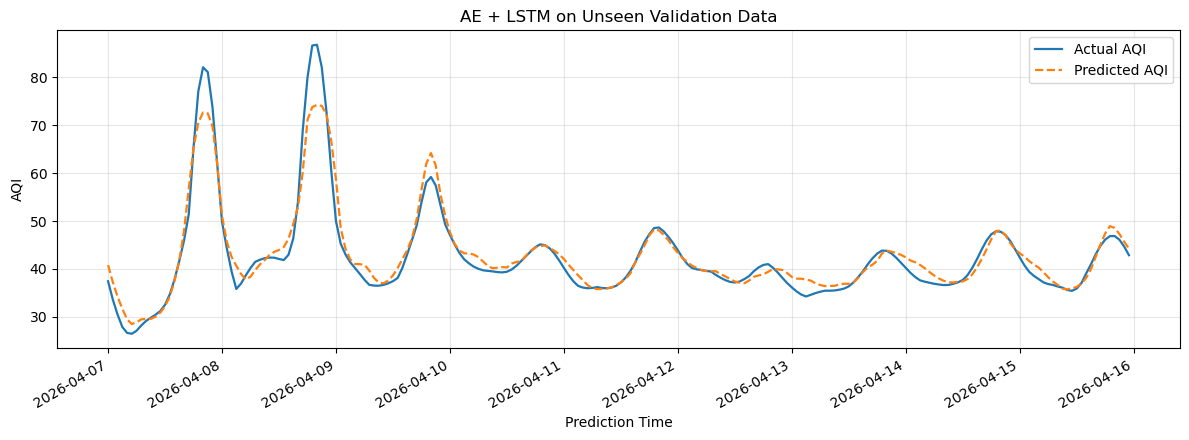

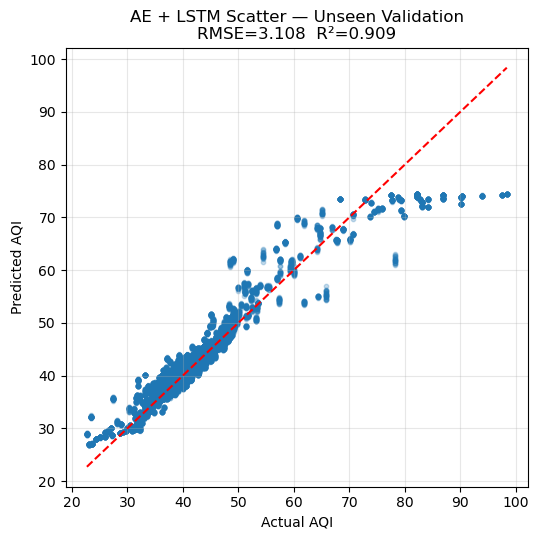

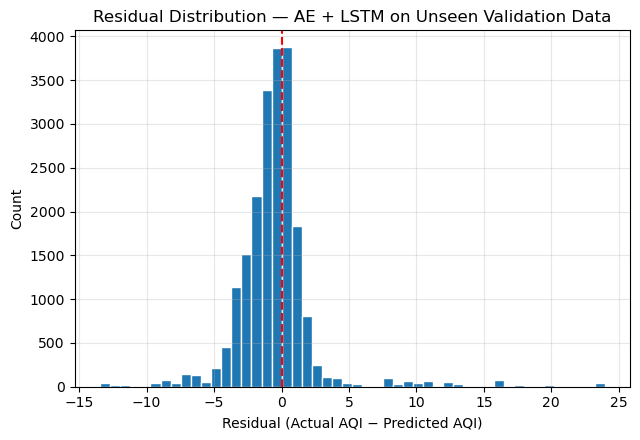

In [34]:
current_external_preds = trainer.predict(lstm_model, X_external_lstm)
current_external_metrics = evaluate_regression(y_external_lstm, current_external_preds, "AE+LSTM [external]")
print_metric_block("Current AE + LSTM external metrics", current_external_metrics)

mean_baseline_pred = np.full_like(y_external_lstm, fill_value=float(np.mean(results["y_train_lstm"])))
mean_baseline_metrics = evaluate_regression(y_external_lstm, mean_baseline_pred, "Mean baseline [external]")
print_metric_block("Mean baseline external metrics", mean_baseline_metrics)

comparison_df = pd.DataFrame([
    {"Model": "AE + LSTM", "RMSE": current_external_metrics["rmse"], "MAE": current_external_metrics["mae"], "R2": current_external_metrics["r2"]},
    {"Model": "Mean baseline", "RMSE": mean_baseline_metrics["rmse"], "MAE": mean_baseline_metrics["mae"], "R2": mean_baseline_metrics["r2"]},
]).sort_values("RMSE")
display(comparison_df)
comparison_df.to_csv(TEX_DIR / "ae_lstm_vs_mean_external.csv", index=False)

plot_pred_vs_actual_over_time(
    external_meta,
    current_external_metrics["y_true"],
    current_external_metrics["y_pred"],
    "AE + LSTM on Unseen Validation Data",
    "ae_lstm_external_timeseries.png",
    aggregate=True,
)

plot_scatter(
    current_external_metrics["y_true"],
    current_external_metrics["y_pred"],
    f"AE + LSTM Scatter — Unseen Validation\nRMSE={current_external_metrics['rmse']:.3f}  R²={current_external_metrics['r2']:.3f}",
    "ae_lstm_external_scatter.png",
)

plt.figure(figsize=(6.5, 4.5))
errors = current_external_metrics["y_true"] - current_external_metrics["y_pred"]
plt.hist(errors, bins=50, edgecolor="white")
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)
plt.title("Residual Distribution — AE + LSTM on Unseen Validation Data")
plt.xlabel("Residual (Actual AQI − Predicted AQI)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "ae_lstm_external_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Grouped validation by prediction time and ZIP

,target_timestamp,RMSE,MAE,R2,N
0,2026-04-12 01:00,0.167798,0.138061,0.953518,97
1,2026-04-12 07:00,0.229572,0.186698,0.977814,97
2,2026-04-14 11:00,0.230902,0.199431,0.976089,97
3,2026-04-10 01:00,0.233666,0.196681,0.802893,97
4,2026-04-12 05:00,0.260008,0.212748,0.965684,97
5,2026-04-12 06:00,0.268124,0.226740,0.968010,97
6,2026-04-15 10:00,0.283656,0.267470,0.950732,97
7,2026-04-10 18:00,0.284676,0.233155,0.932462,97
8,2026-04-12 12:00,0.291790,0.211516,0.968883,97
9,2026-04-13 15:00,0.311325,0.284802,0.930266,97


,zip,RMSE,MAE,R2,N
0,77073,1.813393,1.299411,0.948960,216
1,77032,1.846712,1.319391,0.947067,216
2,77060,1.856609,1.329589,0.946499,216
3,77093,1.869112,1.340912,0.945776,216
4,77037,1.872319,1.338177,0.945589,216
5,77039,1.872350,1.340234,0.945588,216
6,77050,1.874872,1.342243,0.945441,216
7,77044,1.877025,1.350107,0.945315,216
8,77076,1.890273,1.350614,0.944541,216
9,77078,1.892679,1.352893,0.944400,216


,target_timestamp,RMSE,MAE,R2,N
0,2026-04-12 01:00,0.167798,0.138061,0.953518,97
1,2026-04-12 07:00,0.229572,0.186698,0.977814,97
2,2026-04-14 11:00,0.230902,0.199431,0.976089,97
3,2026-04-10 01:00,0.233666,0.196681,0.802893,97
4,2026-04-12 05:00,0.260008,0.212748,0.965684,97


,target_timestamp,RMSE,MAE,R2,N
215,2026-04-08 19:00,14.250924,12.869019,-4.043101,97
214,2026-04-08 20:00,14.148846,12.532627,-3.456364,97
213,2026-04-07 20:00,11.224380,9.771881,-1.078735,97
212,2026-04-07 21:00,10.741722,9.109551,-0.566126,97
211,2026-04-08 21:00,10.469249,8.094941,-1.355602,97


,zip,RMSE,MAE,R2,N
0,77073,1.813393,1.299411,0.948960,216
1,77032,1.846712,1.319391,0.947067,216
2,77060,1.856609,1.329589,0.946499,216
3,77093,1.869112,1.340912,0.945776,216
4,77037,1.872319,1.338177,0.945589,216


,zip,RMSE,MAE,R2,N
96,77067,4.028365,2.150284,0.888074,216
95,77018,4.022908,2.171243,0.888377,216
94,77086,4.020044,2.152594,0.888536,216
93,77092,4.017901,2.170823,0.888655,216
92,77040,4.008867,2.153071,0.889155,216


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


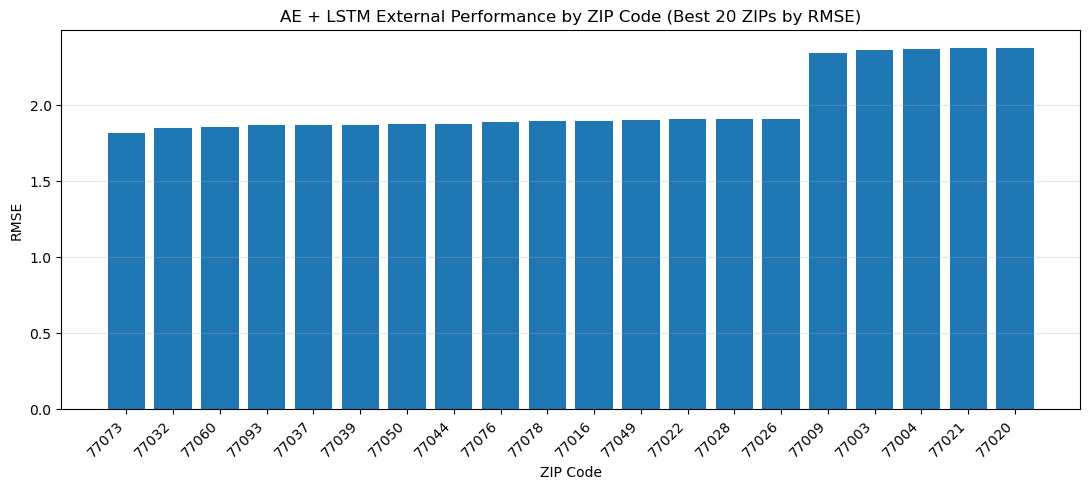

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


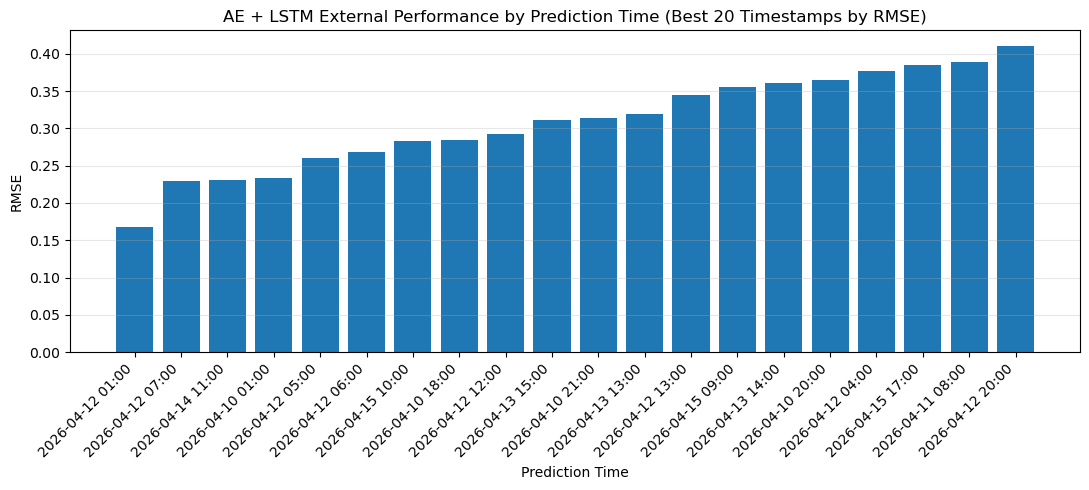

In [35]:
ae_lstm_by_time = group_metrics(external_meta, y_external_lstm, current_external_preds, "target_timestamp", "AE + LSTM")
ae_lstm_by_zip = group_metrics(external_meta, y_external_lstm, current_external_preds, "zip", "AE + LSTM")

display(ae_lstm_by_time.head(10))
display(ae_lstm_by_zip.head(10))

ae_lstm_by_time.to_csv(TEX_DIR / "ae_lstm_external_by_time.csv", index=False)
ae_lstm_by_zip.to_csv(TEX_DIR / "ae_lstm_external_by_zip.csv", index=False)

best_5_times = ae_lstm_by_time.head(5).copy()
worst_5_times = ae_lstm_by_time.sort_values("RMSE", ascending=False).head(5).copy()
best_5_zips = ae_lstm_by_zip.head(5).copy()
worst_5_zips = ae_lstm_by_zip.sort_values("RMSE", ascending=False).head(5).copy()

display(best_5_times)
display(worst_5_times)
display(best_5_zips)
display(worst_5_zips)

best_5_times.to_csv(TEX_DIR / "best_5_times.csv", index=False)
worst_5_times.to_csv(TEX_DIR / "worst_5_times.csv", index=False)
best_5_zips.to_csv(TEX_DIR / "best_5_zips.csv", index=False)
worst_5_zips.to_csv(TEX_DIR / "worst_5_zips.csv", index=False)

plot_group_bar(
    ae_lstm_by_zip,
    x_col="zip",
    y_col="RMSE",
    title="AE + LSTM External Performance by ZIP Code (Best 20 ZIPs by RMSE)",
    xlabel="ZIP Code",
    ylabel="RMSE",
    filename="ae_lstm_external_rmse_by_zip_best20.png",
    top_n=min(20, len(ae_lstm_by_zip)),
)

plot_group_bar(
    ae_lstm_by_time,
    x_col="target_timestamp",
    y_col="RMSE",
    title="AE + LSTM External Performance by Prediction Time (Best 20 Timestamps by RMSE)",
    xlabel="Prediction Time",
    ylabel="RMSE",
    filename="ae_lstm_external_rmse_by_time_best20.png",
    top_n=min(20, len(ae_lstm_by_time)),
)

## 8. Re-run traditional ML baselines on the updated datasets

,Model,Internal_RMSE,Internal_MAE,Internal_R2,External_RMSE,External_MAE,External_R2
0,Ridge,1.324088,0.771931,0.985327,1.139187,0.614276,0.987278
1,ElasticNet,1.326171,0.759397,0.985281,1.151600,0.608103,0.986999
2,GradientBoosting,1.493463,0.836278,0.981333,1.416438,0.757289,0.980332
3,RandomForest,1.820334,0.922517,0.972268,1.610043,0.817580,0.974588
4,LinearRegression,3.073536,1.988305,0.920940,2.805019,1.631704,0.922867
5,KNN,6.675175,4.511703,0.627088,5.031904,3.228089,0.751781


Best traditional model on external RMSE: Ridge


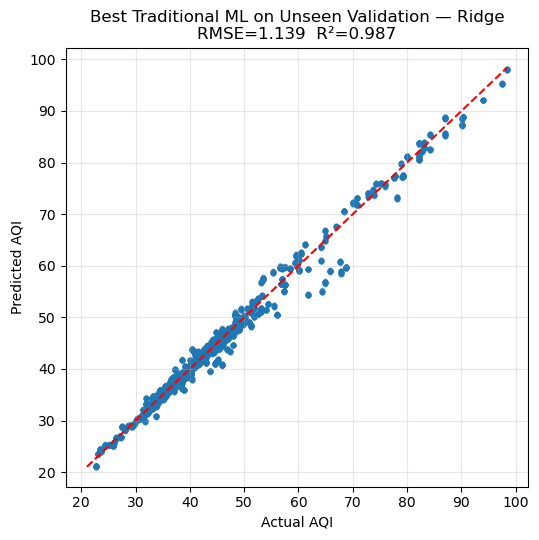

,Model,RMSE,MAE,R2
0,Ridge,1.139187,0.614276,0.987278
1,ElasticNet,1.151600,0.608103,0.986999
2,GradientBoosting,1.416438,0.757289,0.980332
3,RandomForest,1.610043,0.817580,0.974588
4,LinearRegression,2.805019,1.631704,0.922867
5,AE + LSTM,3.108009,1.821376,0.909435
6,KNN,5.031904,3.228089,0.751781
7,Mean baseline,10.383670,6.813434,-0.010880


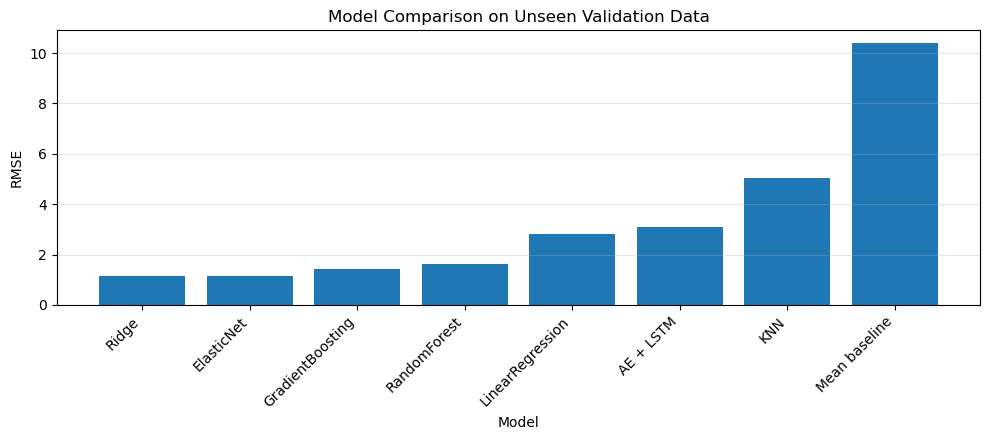

In [ ]:
train_ml_df, val_ml_df = make_row_level_split(train_all_df.dropna().copy(), cfg)
cfg.target_col = pipeline.target_col

ml_drop_cols = ["time", "zip", cfg.target_col]
ml_feature_cols = [c for c in train_ml_df.columns if c not in ml_drop_cols]

external_ml_df = external_aligned_df.copy()
external_ml_df["time"] = pd.to_datetime(external_ml_df["time"])
external_ml_df = external_ml_df.sort_values(["zip", "time"]).reset_index(drop=True)
external_ml_df = external_ml_df.dropna(subset=ml_feature_cols + [cfg.target_col]).copy()

X_train_ml = train_ml_df[ml_feature_cols].to_numpy(dtype=np.float32)
y_train_ml = train_ml_df[cfg.target_col].to_numpy(dtype=np.float32)
X_val_ml = val_ml_df[ml_feature_cols].to_numpy(dtype=np.float32)
y_val_ml = val_ml_df[cfg.target_col].to_numpy(dtype=np.float32)
X_external_ml = external_ml_df[ml_feature_cols].to_numpy(dtype=np.float32)
y_external_ml = external_ml_df[cfg.target_col].to_numpy(dtype=np.float32)

ml_summary, ml_fitted_models, ml_results = train_and_eval_ml_models(
    X_train_ml, y_train_ml, X_val_ml, y_val_ml, X_external_ml, y_external_ml
)
display(ml_summary)
ml_summary.to_csv(TEX_DIR / "traditional_ml_summary.csv", index=False)

best_ml_name = ml_summary.iloc[0]["Model"]
best_ml_model = ml_fitted_models[best_ml_name]
print(f"Best traditional model on external RMSE: {best_ml_name}")

best_ml_external = ml_results[best_ml_name]["external"]
plot_scatter(
    best_ml_external["y_true"],
    best_ml_external["y_pred"],
    f"Best Traditional ML on Unseen Validation — {best_ml_name}\nRMSE={best_ml_external['rmse']:.3f}  R²={best_ml_external['r2']:.3f}",
    "best_traditional_ml_external_scatter.png",
)


all_model_rows = [
    {"Model": "Mean baseline", "RMSE": mean_baseline_metrics["rmse"], "MAE": mean_baseline_metrics["mae"], "R2": mean_baseline_metrics["r2"]},
    {"Model": "AE + LSTM", "RMSE": current_external_metrics["rmse"], "MAE": current_external_metrics["mae"], "R2": current_external_metrics["r2"]},
]
for _, row in ml_summary.iterrows():
    all_model_rows.append({
        "Model": row["Model"],
        "RMSE": row["External_RMSE"],
        "MAE": row["External_MAE"],
        "R2": row["External_R2"],
    })

all_model_df = pd.DataFrame(all_model_rows).sort_values("RMSE").reset_index(drop=True)
display(all_model_df)
all_model_df.to_csv(TEX_DIR / "all_model_comparison_external.csv", index=False)

plt.figure(figsize=(10, 4.5))
plt.bar(all_model_df["Model"], all_model_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Comparison on Unseen Validation Data")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "all_model_rmse_external.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Dataset diagnostics and train-vs-validation shift checks

,Dataset,Rows,Cols,MissingCells,ColumnsWithMissing,DuplicateRows,ZIPs
0,Training dataset,95448,177,174600,144,0,97
1,Unseen validation dataset,25608,177,174600,144,0,97


,Feature,CorrelationWithAQI
0,us_aqi_past_1,0.977862
1,us_aqi_past_2,0.920906
2,us_aqi_past_3,0.843833
3,us_aqi_past_4,0.759522
4,us_aqi_past_5,0.677850
5,us_aqi_past_6,0.604958
6,pm2_5_past_12,0.589584
7,pm2_5_past_11,0.588233
8,pm2_5_past_13,0.583171
9,pm2_5_past_10,0.578762


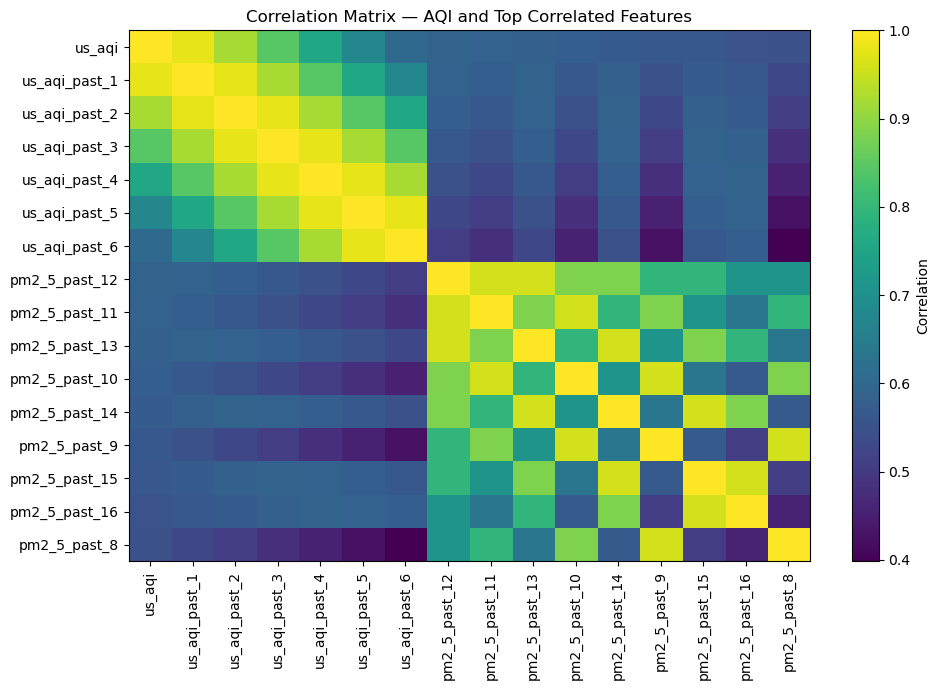

,Feature,TrainMean,TrainStd,ExternalMean,ExternalStd
0,pm2_5,9.221372,4.624491,7.734669,2.444310
1,ozone,76.649453,25.316065,85.325914,19.264422
2,wind_speed_10m,11.766373,5.386127,12.059247,3.835491
3,temperature_2m,20.450761,5.533751,21.098756,3.620706
4,relative_humidity_2m,71.991370,21.559999,74.600459,18.656793
5,cloud_cover,49.134922,42.609879,67.950289,35.459731
6,us_aqi,43.362579,10.431649,41.302749,9.984048


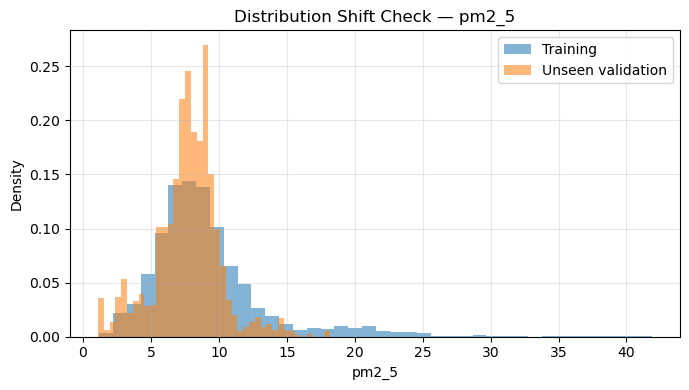

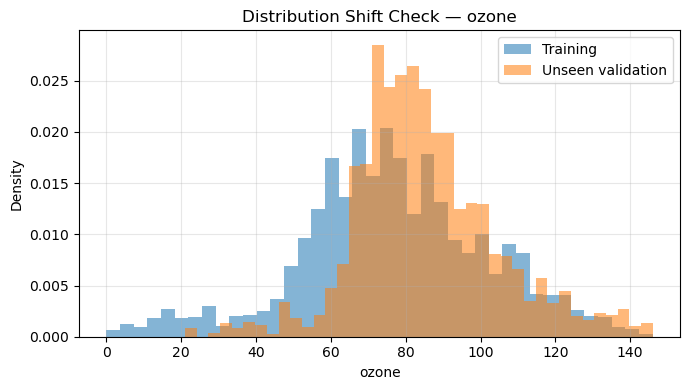

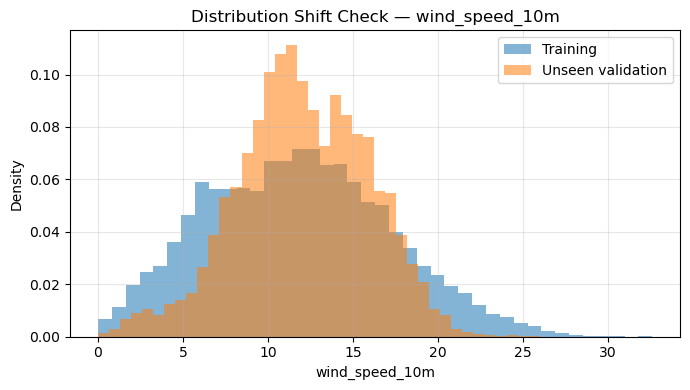

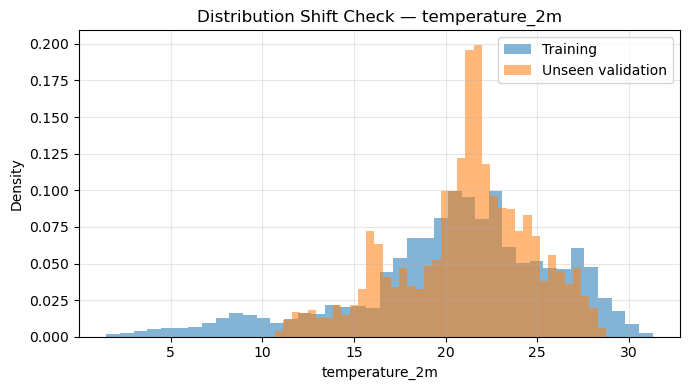

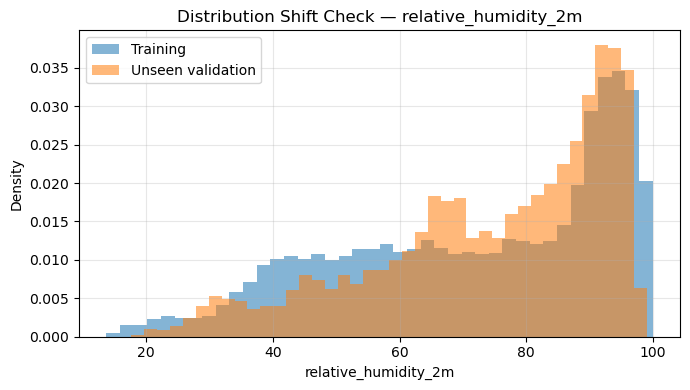

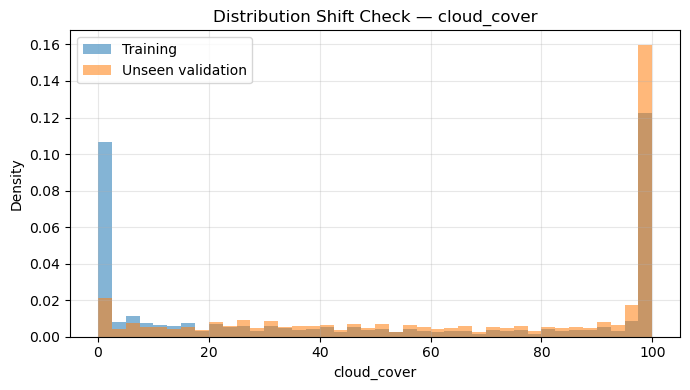

In [38]:
dataset_diagnostics_rows = []
for label, df in [
    ("Training dataset", train_all_df),
    ("Unseen validation dataset", external_aligned_df),
]:
    missing_cells = int(df.isna().sum().sum())
    missing_cols = int((df.isna().sum() > 0).sum())
    duplicate_rows = int(df.duplicated().sum())
    dataset_diagnostics_rows.append({
        "Dataset": label,
        "Rows": len(df),
        "Cols": df.shape[1],
        "MissingCells": missing_cells,
        "ColumnsWithMissing": missing_cols,
        "DuplicateRows": duplicate_rows,
        "ZIPs": df["zip"].nunique() if "zip" in df.columns else np.nan,
    })

dataset_diagnostics_df = pd.DataFrame(dataset_diagnostics_rows)
display(dataset_diagnostics_df)
dataset_diagnostics_df.to_csv(TEX_DIR / "dataset_diagnostics_summary.csv", index=False)

numeric_train = train_all_df.select_dtypes(include=[np.number]).copy()
corr_with_target = (
    numeric_train.corr(numeric_only=True)[cfg.target_col]
    .drop(cfg.target_col)
    .sort_values(key=lambda s: np.abs(s), ascending=False)
)

corr_top = corr_with_target.head(25).reset_index()
corr_top.columns = ["Feature", "CorrelationWithAQI"]
display(corr_top)
corr_top.to_csv(TEX_DIR / "top_correlations_with_aqi.csv", index=False)

plt.figure(figsize=(10, 7))
top_corr_features = [cfg.target_col] + corr_top["Feature"].head(15).tolist()
corr_matrix = numeric_train[top_corr_features].corr()
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(top_corr_features)), top_corr_features, rotation=90)
plt.yticks(range(len(top_corr_features)), top_corr_features)
plt.title("Correlation Matrix — AQI and Top Correlated Features")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "correlation_matrix_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

available_shift_features = [
    c for c in [
        "pm2_5", "ozone", "wind_speed_10m", "temperature_2m",
        "relative_humidity_2m", "cloud_cover", "us_aqi"
    ] if c in train_all_df.columns and c in external_aligned_df.columns
]
shift_rows = []
for feature in available_shift_features:
    shift_rows.append({
        "Feature": feature,
        "TrainMean": float(train_all_df[feature].mean()),
        "TrainStd": float(train_all_df[feature].std()),
        "ExternalMean": float(external_aligned_df[feature].mean()),
        "ExternalStd": float(external_aligned_df[feature].std()),
    })
shift_df = pd.DataFrame(shift_rows)
display(shift_df)
shift_df.to_csv(TEX_DIR / "train_vs_external_shift_summary.csv", index=False)

for feature in available_shift_features[:6]:
    plt.figure(figsize=(7, 4))
    plt.hist(train_all_df[feature].dropna(), bins=40, alpha=0.55, label="Training", density=True)
    plt.hist(external_aligned_df[feature].dropna(), bins=40, alpha=0.55, label="Unseen validation", density=True)
    plt.title(f"Distribution Shift Check — {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"shift_{feature}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10. Permutation importance on the best traditional model

,Feature,ImportanceMean,ImportanceStd
0,us_aqi_past_1,6.185926,0.040957
1,us_aqi_past_2,2.549228,0.019960
2,us_aqi_past_3,0.317311,0.003347
3,us_aqi_past_4,0.070469,0.000704
4,us_aqi_past_21,0.016877,0.000209
5,ozone_past_9,0.016122,0.000157
6,us_aqi_past_23,0.014980,0.000118
7,us_aqi_past_24,0.009026,0.000096
8,ozone,0.008300,0.000076
9,ozone_past_20,0.008267,0.000116


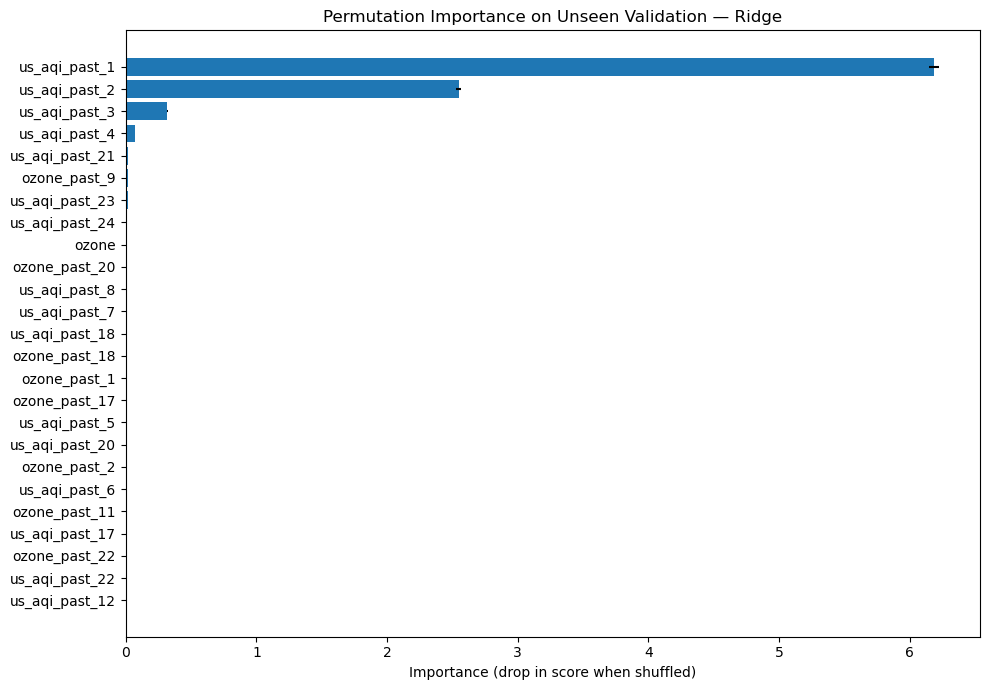

In [39]:
perm = permutation_importance(
    best_ml_model,
    X_external_ml,
    y_external_ml,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": ml_feature_cols,
    "ImportanceMean": perm.importances_mean,
    "ImportanceStd": perm.importances_std,
}).sort_values("ImportanceMean", ascending=False).reset_index(drop=True)

top_perm = perm_df.head(25)
display(top_perm)
top_perm.to_csv(TEX_DIR / "permutation_importance_top25.csv", index=False)

plt.figure(figsize=(10, 7))
plt.barh(top_perm["Feature"][::-1], top_perm["ImportanceMean"][::-1], xerr=top_perm["ImportanceStd"][::-1])
plt.title(f"Permutation Importance on Unseen Validation — {best_ml_name}")
plt.xlabel("Importance (drop in score when shuffled)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "permutation_importance_top25.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. AE usefulness test — compare final AE + LSTM to a raw-feature LSTM under the same model-3 preprocessing

In [40]:
X_train_raw_seq, y_train_raw_seq, X_val_raw_seq, y_val_raw_seq, X_external_raw_seq, y_external_raw_seq, external_raw_meta = build_raw_lstm_inputs(
    train_df=pipeline.train_df,
    val_df=pipeline.val_df,
    external_df=external_aligned_df,
    cfg=cfg,
    pipeline=pipeline,
)

print("Raw LSTM external seq shape:", X_external_raw_seq.shape)
if X_external_raw_seq.shape[0] == 0:
    raise ValueError("No external raw sequences were formed. Check the external validation data and lookback window.")

raw_lstm_cfg = Config(
    all_data_path=cfg.all_data_path,
    external_validation_path=cfg.external_validation_path,
    save_dir=str(MODELS_DIR / "raw_lstm_artifacts"),
    show_plots=False,
)
raw_lstm_cfg.lstm_hidden = min(256, cfg.lstm_hidden)
raw_lstm_cfg.lstm_layers = cfg.lstm_layers
raw_lstm_cfg.lstm_dropout = cfg.lstm_dropout
raw_lstm_cfg.lstm_epochs = max(30, min(cfg.lstm_epochs, 60))
raw_lstm_cfg.lstm_lr = cfg.lstm_lr
raw_lstm_cfg.patience = cfg.patience
raw_lstm_cfg.lstm_batch_size = cfg.lstm_batch_size

raw_lstm_model = AQI_LSTM(
    input_dim=X_train_raw_seq.shape[2],
    hidden_size=raw_lstm_cfg.lstm_hidden,
    num_layers=raw_lstm_cfg.lstm_layers,
    dropout=raw_lstm_cfg.lstm_dropout,
)
raw_trainer = LSTMTrainer(raw_lstm_cfg)

raw_loss_curves = raw_trainer.train(
    raw_lstm_model,
    X_train_raw_seq,
    y_train_raw_seq,
    X_val_raw_seq,
    y_val_raw_seq,
    name="RawLSTM"
)

raw_val_preds = raw_trainer.predict(raw_lstm_model, X_val_raw_seq)
raw_val_metrics = evaluate_regression(y_val_raw_seq, raw_val_preds, "Raw LSTM [internal val]")
print_metric_block("Raw LSTM internal validation metrics", raw_val_metrics)

raw_external_preds = raw_trainer.predict(raw_lstm_model, X_external_raw_seq)
raw_external_metrics = evaluate_regression(y_external_raw_seq, raw_external_preds, "Raw LSTM [external]")
print_metric_block("Raw LSTM external metrics", raw_external_metrics)

ae_vs_raw_df = pd.DataFrame([
    {"Model": "AE + LSTM", "Split": "Internal validation", "RMSE": internal_metrics["rmse"], "MAE": internal_metrics["mae"], "R2": internal_metrics["r2"]},
    {"Model": "AE + LSTM", "Split": "Unseen validation", "RMSE": current_external_metrics["rmse"], "MAE": current_external_metrics["mae"], "R2": current_external_metrics["r2"]},
    {"Model": "Raw LSTM", "Split": "Internal validation", "RMSE": raw_val_metrics["rmse"], "MAE": raw_val_metrics["mae"], "R2": raw_val_metrics["r2"]},
    {"Model": "Raw LSTM", "Split": "Unseen validation", "RMSE": raw_external_metrics["rmse"], "MAE": raw_external_metrics["mae"], "R2": raw_external_metrics["r2"]},
])
display(ae_vs_raw_df)
ae_vs_raw_df.to_csv(TEX_DIR / "ae_vs_raw_lstm.csv", index=False)

Raw LSTM external seq shape: (20952, 24, 70)
    [RawLSTM] Epoch   1/50  train=1941.270562  test=1681.070984
    [RawLSTM] Epoch   5/50  train=1080.758714  test=905.389099
    [RawLSTM] Epoch  10/50  train=594.606533  test=473.746239
    [RawLSTM] Epoch  15/50  train=280.847282  test=210.423084
    [RawLSTM] Epoch  20/50  train=123.840292  test=103.260099
    [RawLSTM] Epoch  25/50  train=62.245656  test=43.119006
    [RawLSTM] Epoch  30/50  train=24.625075  test=17.422354
    [RawLSTM] Epoch  35/50  train=8.814092  test=9.853974
    [RawLSTM] Epoch  40/50  train=2.950261  test=8.278213
    [RawLSTM] Epoch  45/50  train=1.480363  test=8.006901
    [RawLSTM] Early stopping at epoch 47

Raw LSTM internal validation metrics
------------------------------------
RMSE=2.6579  MAE=1.5861  R²=0.9296

Raw LSTM external metrics
-------------------------
RMSE=3.3172  MAE=1.8872  R²=0.8968


,Model,Split,RMSE,MAE,R2
0,AE + LSTM,Internal validation,2.611587,1.525086,0.932009
1,AE + LSTM,Unseen validation,3.108009,1.821376,0.909435
2,Raw LSTM,Internal validation,2.657912,1.586102,0.929575
3,Raw LSTM,Unseen validation,3.317250,1.887160,0.896830


## 12. Consensus feature-finding summary

,Feature,Spearman_rho,Spearman_pval,Spearman_abs
0,us_aqi_past_1,0.981829,0.0,0.981829
1,us_aqi_past_2,0.932740,0.0,0.932740
2,us_aqi_past_3,0.859968,0.0,0.859968
3,us_aqi_past_4,0.771025,0.0,0.771025
4,us_aqi_past_5,0.673971,0.0,0.673971
5,us_aqi_past_6,0.576313,0.0,0.576313
6,us_aqi_past_7,0.484011,0.0,0.484011
7,us_aqi_past_23,0.462317,0.0,0.462317
8,us_aqi_past_22,0.455079,0.0,0.455079
9,ozone_past_4,0.453257,0.0,0.453257


,Feature,MDI_Importance
0,us_aqi_past_1,0.946068
1,ozone_past_4,0.020730
2,ozone_past_5,0.004289
3,ozone_past_8,0.003853
4,ozone_past_7,0.003347
5,ozone_past_3,0.002090
6,ozone_past_10,0.001786
7,us_aqi_past_3,0.001785
8,ozone_past_1,0.001584
9,ozone_past_2,0.001263


,Feature,VIF
0,us_aqi_past_3,628.978806
1,us_aqi_past_4,560.412818
2,us_aqi_past_2,477.876915
3,ozone_past_6,347.111109
4,ozone_past_5,344.771806
5,ozone_past_7,343.617163
6,ozone_past_3,340.921066
7,ozone_past_8,339.226266
8,ozone_past_4,338.437883
9,ozone_past_2,335.835290


,Feature,Spearman_abs,MDI_Importance,Permutation_Mean,Variance,Spearman_norm,MDI_norm,Permutation_norm,Variance_norm,Consensus_Score,Low_Variance,High_VIF,Verdict
0,us_aqi_past_1,0.981829,0.946068,6.185926,106.636812,1.000000,1.000000,1.000000,0.001260,0.900126,False,True,IMPORTANT
1,us_aqi_past_2,0.932740,0.000986,2.549228,106.472577,0.949990,0.001042,0.412122,0.001258,0.382179,False,True,MARGINAL
2,us_aqi_past_3,0.859968,0.001785,0.317311,106.141954,0.875853,0.001887,0.051329,0.001254,0.237620,False,True,MARGINAL
3,us_aqi_past_4,0.771025,0.000900,0.070469,105.849531,0.785241,0.000951,0.011427,0.001251,0.200720,False,True,MARGINAL
4,us_aqi_past_5,0.673971,0.000094,0.005763,105.742260,0.686366,0.000099,0.000967,0.001250,0.172085,False,True,MARGINAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,wind_direction_100m_sin_past_7,0.009226,0.000015,0.000002,0.166155,0.009149,0.000016,0.000036,0.000002,0.002305,False,False,USELESS
170,wind_direction_100m_sin_past_8,0.008619,0.000016,-0.000002,0.165629,0.008531,0.000017,0.000035,0.000002,0.002150,False,False,USELESS
171,wind_direction_100m_cos_past_1,0.003303,0.000007,-0.000071,0.414840,0.003115,0.000008,0.000024,0.000005,0.000790,False,False,USELESS
172,wind_gusts_10m,0.001765,0.000012,-0.000002,152.488669,0.001548,0.000013,0.000035,0.001802,0.000583,False,False,USELESS


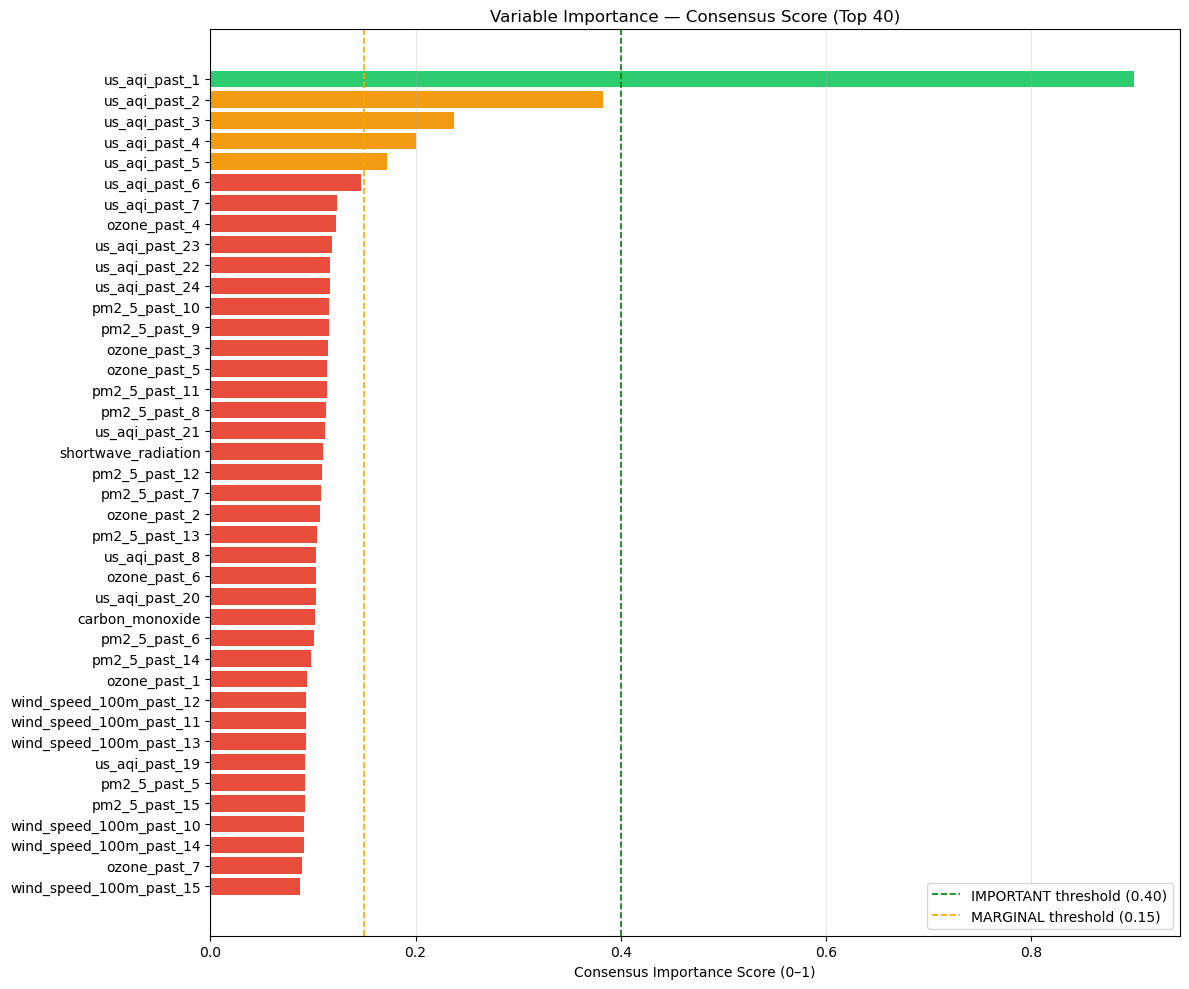

In [41]:
numeric_ml_train = train_ml_df[ml_feature_cols].copy()

spearman_rows = []
for col in ml_feature_cols:
    series = numeric_ml_train[col].dropna()
    target = train_ml_df.loc[series.index, cfg.target_col]
    if len(series) < 30 or series.std() < 1e-8:
        rho, pval = 0.0, 1.0
    else:
        rho, pval = spearmanr(series, target)
    spearman_rows.append({"Feature": col, "Spearman_rho": rho, "Spearman_pval": pval})

spearman_df = (
    pd.DataFrame(spearman_rows)
    .assign(Spearman_abs=lambda d: d["Spearman_rho"].abs())
    .sort_values("Spearman_abs", ascending=False)
    .reset_index(drop=True)
)
display(spearman_df.head(25))
spearman_df.to_csv(TEX_DIR / "spearman_correlation.csv", index=False)

rf_model = ml_fitted_models.get("RandomForest")
if rf_model is not None:
    mdi_df = (
        pd.DataFrame({"Feature": ml_feature_cols, "MDI_Importance": rf_model.feature_importances_})
        .sort_values("MDI_Importance", ascending=False)
        .reset_index(drop=True)
    )
else:
    mdi_df = pd.DataFrame({"Feature": ml_feature_cols, "MDI_Importance": np.nan})

display(mdi_df.head(25))
mdi_df.to_csv(TEX_DIR / "rf_mdi_importance.csv", index=False)

perm_importance_df = perm_df.rename(columns={
    "ImportanceMean": "Permutation_Mean",
    "ImportanceStd": "Permutation_Std",
}).copy()

var_df = (
    numeric_ml_train.var()
    .reset_index()
    .rename(columns={"index": "Feature", 0: "Variance"})
)
VAR_THRESHOLD = 1e-2
low_var_features = var_df.loc[var_df["Variance"] < VAR_THRESHOLD, "Feature"].tolist()
var_df.to_csv(TEX_DIR / "feature_variance.csv", index=False)

vif_candidate_cols = mdi_df["Feature"].head(50).tolist()
for f in low_var_features:
    if f not in vif_candidate_cols:
        vif_candidate_cols.append(f)

X_vif_raw = numeric_ml_train[vif_candidate_cols].dropna()
X_vif = X_vif_raw.assign(_const=1.0).values.astype(np.float64)

vif_rows = []
for i, col in enumerate(vif_candidate_cols):
    try:
        vif_val = variance_inflation_factor(X_vif, i)
    except Exception:
        vif_val = np.nan
    vif_rows.append({"Feature": col, "VIF": vif_val})

vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False).reset_index(drop=True)
HIGH_VIF = 10.0
high_vif_features = vif_df.loc[vif_df["VIF"] > HIGH_VIF, "Feature"].tolist()
display(vif_df.head(25))
vif_df.to_csv(TEX_DIR / "vif_scores.csv", index=False)

consensus = (
    pd.DataFrame({"Feature": ml_feature_cols})
    .merge(spearman_df[["Feature", "Spearman_abs"]], on="Feature", how="left")
    .merge(mdi_df[["Feature", "MDI_Importance"]], on="Feature", how="left")
    .merge(perm_importance_df[["Feature", "Permutation_Mean"]], on="Feature", how="left")
    .merge(var_df[["Feature", "Variance"]], on="Feature", how="left")
)

consensus["Spearman_norm"] = minmax_norm(consensus["Spearman_abs"].fillna(0))
consensus["MDI_norm"] = minmax_norm(consensus["MDI_Importance"].fillna(0))
consensus["Permutation_norm"] = minmax_norm(consensus["Permutation_Mean"].fillna(0))
consensus["Variance_norm"] = minmax_norm(consensus["Variance"].fillna(0))

consensus["Consensus_Score"] = (
    consensus["Spearman_norm"] * 0.25 +
    consensus["MDI_norm"] * 0.30 +
    consensus["Permutation_norm"] * 0.35 +
    consensus["Variance_norm"] * 0.10
)

consensus.loc[consensus["Feature"].isin(low_var_features), "Consensus_Score"] *= 0.1
consensus["Low_Variance"] = consensus["Feature"].isin(low_var_features)
consensus["High_VIF"] = consensus["Feature"].isin(high_vif_features)

def classify_feature(row):
    if row["Low_Variance"]:
        return "USELESS (near-zero variance)"
    if row["Consensus_Score"] >= 0.40:
        return "IMPORTANT"
    if row["Consensus_Score"] >= 0.15:
        return "MARGINAL"
    return "USELESS"

consensus["Verdict"] = consensus.apply(classify_feature, axis=1)
consensus = consensus.sort_values("Consensus_Score", ascending=False).reset_index(drop=True)
display(consensus)
consensus.to_csv(TEX_DIR / "consensus_variable_importance.csv", index=False)

top40 = consensus.head(40).copy()
colour_map = {"IMPORTANT": "#2ecc71", "MARGINAL": "#f39c12"}
colours = [colour_map.get(v, "#e74c3c") for v in top40["Verdict"]]

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(top40["Feature"][::-1], top40["Consensus_Score"][::-1], color=colours[::-1])
ax.set_xlabel("Consensus Importance Score (0–1)")
ax.set_title("Variable Importance — Consensus Score (Top 40)")
ax.axvline(0.40, color="green", linestyle="--", linewidth=1.2, label="IMPORTANT threshold (0.40)")
ax.axvline(0.15, color="orange", linestyle="--", linewidth=1.2, label="MARGINAL threshold (0.15)")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "consensus_importance_top40.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Final written summary for the final AQI validation run

In [42]:
summary_lines = []

summary_lines.append("Final AQI validation summary")
summary_lines.append("=" * 40)
summary_lines.append(f"AE + LSTM internal RMSE: {internal_metrics['rmse']:.4f}")
summary_lines.append(f"AE + LSTM external RMSE: {current_external_metrics['rmse']:.4f}")
summary_lines.append(f"Mean baseline external RMSE: {mean_baseline_metrics['rmse']:.4f}")
summary_lines.append(f"Best traditional ML external RMSE: {ml_summary.iloc[0]['External_RMSE']:.4f} ({best_ml_name})")

if current_external_metrics["rmse"] >= mean_baseline_metrics["rmse"]:
    summary_lines.append("- The neural model is not clearly beating the mean baseline on the unseen validation data.")
else:
    summary_lines.append("- The neural model beats the mean baseline on the unseen validation data.")

if ml_summary.iloc[0]["External_RMSE"] < current_external_metrics["rmse"]:
    summary_lines.append("- The best traditional ML baseline outperforms the current AE + LSTM on unseen data.")
else:
    summary_lines.append("- The AE + LSTM is competitive with or better than the best traditional ML baseline on unseen data.")

best_corr_feats = corr_top["Feature"].head(10).tolist()
summary_lines.append(f"- Top correlated features with AQI: {best_corr_feats}")

best_perm_feats = top_perm["Feature"].head(10).tolist()
summary_lines.append(f"- Top permutation-importance features from the best ML model: {best_perm_feats}")

if "ae_vs_raw_df" in globals():
    ae_external_rmse = float(ae_vs_raw_df.query("Model == 'AE + LSTM' and Split == 'Unseen validation'")["RMSE"].iloc[0])
    raw_external_rmse = float(ae_vs_raw_df.query("Model == 'Raw LSTM' and Split == 'Unseen validation'")["RMSE"].iloc[0])
    if raw_external_rmse < ae_external_rmse:
        summary_lines.append("- Raw-feature LSTM beats AE + LSTM on the unseen data, suggesting AE compression may remove useful signal.")
    else:
        summary_lines.append("- AE + LSTM beats raw-feature LSTM on the unseen data, suggesting the AE compression is helpful.")

summary_lines.append("- Best 5 ZIPs by RMSE:")
for _, row in best_5_zips.iterrows():
    summary_lines.append(f"  • ZIP {row['zip']}: RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, R²={row['R2']:.4f}, N={int(row['N'])}")

summary_lines.append("- Worst 5 ZIPs by RMSE:")
for _, row in worst_5_zips.iterrows():
    summary_lines.append(f"  • ZIP {row['zip']}: RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, R²={row['R2']:.4f}, N={int(row['N'])}")

summary_lines.append("- Best 5 timestamps by RMSE:")
for _, row in best_5_times.iterrows():
    summary_lines.append(f"  • {row['target_timestamp']}: RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, R²={row['R2']:.4f}, N={int(row['N'])}")

summary_lines.append("- Worst 5 timestamps by RMSE:")
for _, row in worst_5_times.iterrows():
    summary_lines.append(f"  • {row['target_timestamp']}: RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, R²={row['R2']:.4f}, N={int(row['N'])}")

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(TEX_DIR / "final_aqi_validation_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

Final AQI validation summary
AE + LSTM internal RMSE: 2.6116
AE + LSTM external RMSE: 3.1080
Mean baseline external RMSE: 10.3837
Best traditional ML external RMSE: 1.1392 (Ridge)
- The neural model beats the mean baseline on the unseen validation data.
- The best traditional ML baseline outperforms the current AE + LSTM on unseen data.
- Top correlated features with AQI: ['us_aqi_past_1', 'us_aqi_past_2', 'us_aqi_past_3', 'us_aqi_past_4', 'us_aqi_past_5', 'us_aqi_past_6', 'pm2_5_past_12', 'pm2_5_past_11', 'pm2_5_past_13', 'pm2_5_past_10']
- Top permutation-importance features from the best ML model: ['us_aqi_past_1', 'us_aqi_past_2', 'us_aqi_past_3', 'us_aqi_past_4', 'us_aqi_past_21', 'ozone_past_9', 'us_aqi_past_23', 'us_aqi_past_24', 'ozone', 'ozone_past_20']
- AE + LSTM beats raw-feature LSTM on the unseen data, suggesting the AE compression is helpful.
- Best 5 ZIPs by RMSE:
  • ZIP 77073.0: RMSE=1.8134, MAE=1.2994, R²=0.9490, N=216
  • ZIP 77032.0: RMSE=1.8467, MAE=1.3194, R²=0.9

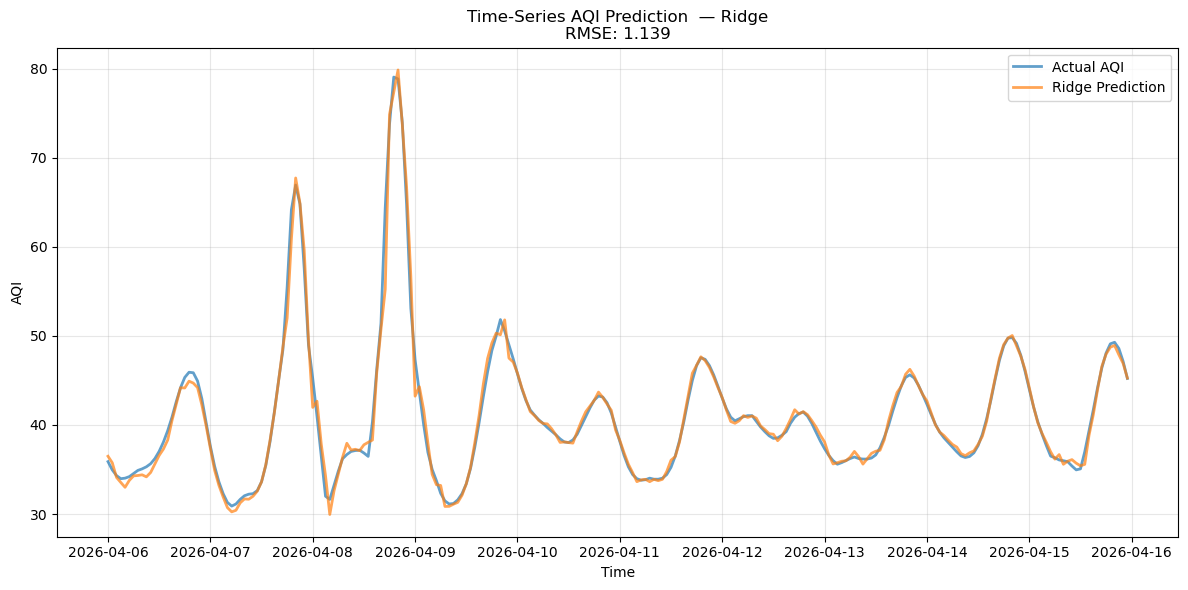

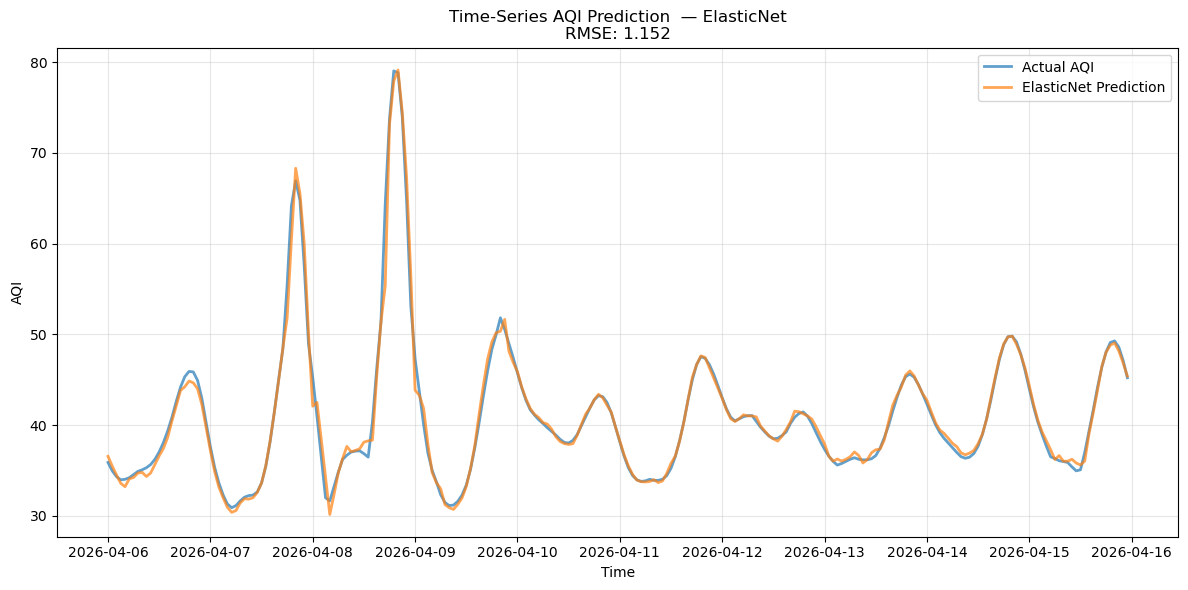

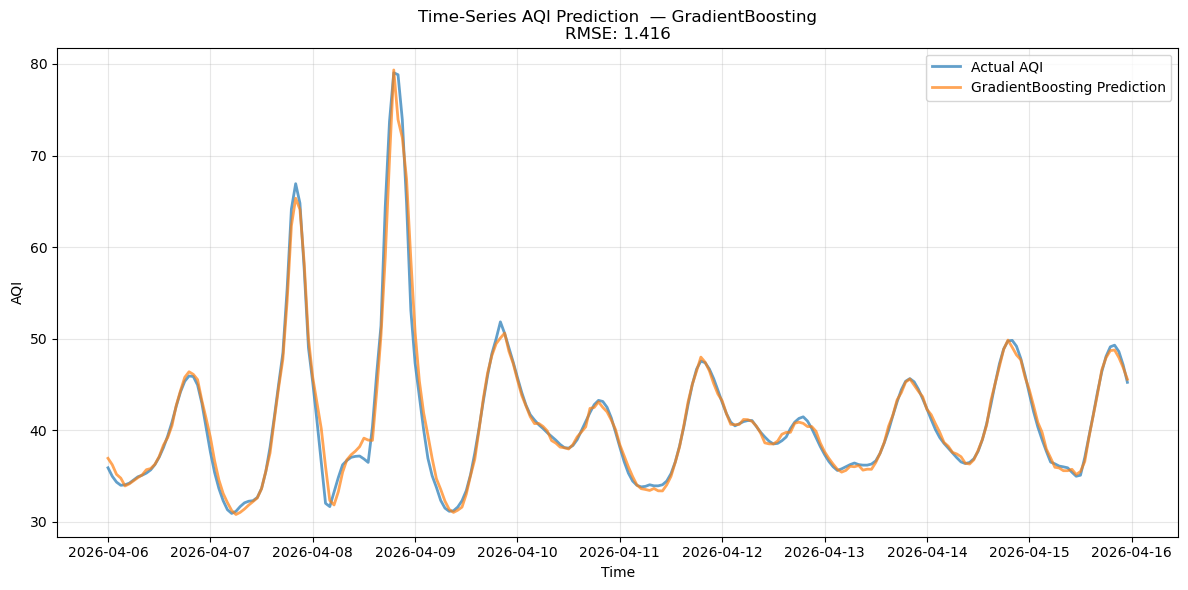

In [44]:
# Plot time-series predictions for the top 3 traditional ML models on unseen data
top_3_ml = ml_summary.head(3)["Model"].tolist()
sample_zip = best_5_zips["zip"].iloc[0]  # Use the best-performing ZIP for visualization

for model in top_3_ml:
    pred_series = pd.Series(ml_results[model]["external"]["y_pred"], index=external_ml_df.index)
    zip_df = external_ml_df[external_ml_df["zip"] == sample_zip].copy()
    zip_df["pred"] = pred_series.loc[zip_df.index]
    
    plt.figure(figsize=(12, 6))
    plt.plot(zip_df["time"], zip_df[cfg.target_col], label="Actual AQI", alpha=0.7, linewidth=2)
    plt.plot(zip_df["time"], zip_df["pred"], label=f"{model} Prediction", alpha=0.7, linewidth=2)
    plt.title(f"Time-Series AQI Prediction  — {model}\nRMSE: {ml_results[model]['external']['rmse']:.3f}")
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"ts_{model.replace(' ', '_')}_zip_{sample_zip}.png", dpi=150, bbox_inches="tight")
    plt.show()